# Part 1: Selecting and analyzing the dataset
<pre>
After getting some results with the first Dataset and the conclusion. This dataset was taken to make the analysis. This Dataset can be model with a regression. Therefore, it is possible to compare resulst.
[link](https://www.kaggle.com/code/monikachdhankhar/health-insurance-claim-prediction-model)
This dataset has variables about health insurance.
it has a total of 13 features, where the goal is to predict the claim based on the different features
</pre>


In [161]:
%load_ext autoreload
%autoreload 2
    
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

import os
import itertools

from NeuralNet import NeuralNet
from helpers import denormalize, save_prediction_to_csv, get_prediction, show_prediction_vs_real_values, create_csv, show_loss

# CSV for saving results
results_df = create_csv()
# dictionary for saving resulsts
metrics = {}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sureshgupta/health-insurance-data-set")

print("Path to dataset files:", path)

/Users/hjaviersarmientoy/miniforge3/envs/jupyter_m1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1


In [3]:
full_file_path = '/Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1/1651277648862_healthinsurance.csv'
df = pd.read_csv(full_file_path)

# Display the first few rows to confirm the import was successful
print(df.head())


    age     sex  weight   bmi hereditary_diseases  no_of_dependents  smoker  \
0  60.0    male      64  24.3           NoDisease                 1       0   
1  49.0  female      75  22.6           NoDisease                 1       0   
2  32.0  female      64  17.8            Epilepsy                 2       1   
3  61.0  female      53  36.4           NoDisease                 1       1   
4  19.0  female      50  20.6           NoDisease                 0       0   

          city  bloodpressure  diabetes  regular_ex    job_title    claim  
0      NewYork             72         0           0        Actor  13112.6  
1       Boston             78         1           1     Engineer   9567.0  
2  Phildelphia             88         1           1  Academician  32734.2  
3    Pittsburg             72         1           0         Chef  48517.6  
4      Buffalo             82         1           0   HomeMakers   1731.7  


In [4]:
df.shape

(15000, 13)

## Pre-processing data

###  Checking null values, we found 396 null values for age and 956 for bmi

In [4]:
df.isnull().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

### Replace null Values
<pre>
we are using the mean imputation method to clean the data by replacing missing entries
in the 'age' and 'bmi' columns with the average value of the existing, non-missing entries 
in those same columns, and then checking to ensure the missing values are gone
</pre>



In [ ]:
imputer = SimpleImputer(strategy='mean')

# Specify the columns with missing values that we want to impute
columns_with_missing_values = ['age', 'bmi']

# Apply the imputer to fill missing values with the mean
df[columns_with_missing_values] = imputer.fit_transform(df[columns_with_missing_values])

df.isnull().sum()

In [6]:
df.describe(include='all')

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
count,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000,15000.000000
unique,NaN,2,NaN,NaN,10,NaN,NaN,91,NaN,NaN,NaN,35,NaN
top,NaN,female,NaN,NaN,NoDisease,NaN,NaN,NewOrleans,NaN,NaN,NaN,Student,NaN
freq,NaN,7652,NaN,NaN,13998,NaN,NaN,302,NaN,NaN,NaN,1320,NaN
mean,39.547521,NaN,64.909600,30.266413,NaN,1.129733,0.198133,NaN,68.650133,0.777000,0.224133,NaN,13401.437620
std,13.829705,NaN,13.701935,5.924606,NaN,1.228469,0.398606,NaN,19.418515,0.416272,0.417024,NaN,12148.239619
min,18.000000,NaN,34.000000,16.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1121.900000
25%,27.000000,NaN,54.000000,25.900000,NaN,0.000000,0.000000,NaN,64.000000,1.000000,0.000000,NaN,4846.900000
50%,40.000000,NaN,63.000000,29.800000,NaN,1.000000,0.000000,NaN,71.000000,1.000000,0.000000,NaN,9545.650000
75%,51.000000,NaN,76.000000,34.100000,NaN,2.000000,0.000000,NaN,80.000000,1.000000,0.000000,NaN,16519.125000


### Hot Encoding
<pre>
    We translate the categorical values to numerical values
    For example:
    male = 1
    female = 0
</pre>

In [7]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [8]:
#values mapped to integers (0 and 1)
df['sex']=df['sex'].map({'female':0,'male':1})
df["sex"].unique()

array([1, 0])

In [9]:
df["hereditary_diseases"].unique()

array(['NoDisease', 'Epilepsy', 'EyeDisease', 'Alzheimer', 'Arthritis',
       'HeartDisease', 'Diabetes', 'Cancer', 'High BP', 'Obesity'],
      dtype=object)

In [10]:
df["hereditary_diseases"]=df["hereditary_diseases"].map({'NoDisease':0, 'Epilepsy':1, 'EyeDisease':2, 'Alzheimer':3, 'Arthritis':4,
       'HeartDisease':5, 'Diabetes':6, 'Cancer':7, 'High BP':8, 'Obesity':9})
df["hereditary_diseases"].unique()
# mapping done

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [11]:
df["city"].unique()

array(['NewYork', 'Boston', 'Phildelphia', 'Pittsburg', 'Buffalo',
       'AtlanticCity', 'Portland', 'Cambridge', 'Hartford', 'Springfield',
       'Syracuse', 'Baltimore', 'York', 'Trenton', 'Warwick',
       'WashingtonDC', 'Providence', 'Harrisburg', 'Newport', 'Stamford',
       'Worcester', 'Atlanta', 'Brimingham', 'Charleston', 'Charlotte',
       'Louisville', 'Memphis', 'Nashville', 'NewOrleans', 'Raleigh',
       'Houston', 'Georgia', 'Oklahoma', 'Orlando', 'Macon', 'Huntsville',
       'Knoxville', 'Florence', 'Miami', 'Tampa', 'PanamaCity',
       'Kingsport', 'Marshall', 'Mandan', 'Waterloo', 'IowaCity',
       'Columbia', 'Indianapolis', 'Cincinnati', 'Bloomington', 'Salina',
       'KanasCity', 'Brookings', 'Minot', 'Chicago', 'Lincoln',
       'FallsCity', 'GrandForks', 'Fargo', 'Cleveland', 'Canton',
       'Columbus', 'Rochester', 'Minneapolis', 'JeffersonCity',
       'Escabana', 'Youngstown', 'SantaRosa', 'Eureka', 'SanFrancisco',
       'SanJose', 'LosAngeles', 'Ox

<pre>
We are performing categorical feature encoding using a technique called Label Encoding. This is a necessary step in data preprocessing we want to convert text-based, non-numeric categorical data into a numerical format, so our models can understand and process.
</pre>

In [12]:
# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Encode the "city" column
df['city'] = label_encoder.fit_transform(df['city'])
df['job_title'] = label_encoder.fit_transform(df['job_title'])
df['city'].unique()

array([55,  5, 63, 64,  8,  1, 65,  9, 29, 79, 81,  3, 89, 83, 85, 86, 67,
       28, 56, 80, 88,  0,  6, 12, 13, 42, 47, 53, 54, 68, 30, 26, 58, 59,
       44, 31, 38, 24, 49, 82, 61, 37, 46, 45, 87, 33, 17, 32, 15,  4, 71,
       35,  7, 51, 14, 40, 22, 27, 23, 16, 10, 18, 70, 50, 34, 20, 90, 77,
       21, 73, 74, 41, 60, 72, 57, 11, 52, 66, 25, 69, 39, 84, 75, 19, 36,
        2, 48, 78, 62, 76, 43])

In [13]:
#label encoding done
df['job_title'].unique()

array([ 2, 16,  0, 10, 22, 12, 32, 13, 30, 33, 15, 28, 29,  5,  8,  6,  9,
       26,  1, 19, 34, 18,  4, 23, 20,  7, 31, 14,  3, 11, 24, 17, 25, 27,
       21])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  int64  
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  int64  
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  int64  
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  int64  
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(10)
memory usage: 1.5 MB


<pre>
Here we are checking the correlation and patterns between all the features.
We can assess the shape of the data for each variable

- Positive Correlation: As the variable on the x-axis increases, the variable on the y-axis also increases. The points will cluster around an upward-sloping line.

- Negative Correlation: As the variable on the x-axis increases, the variable on the y-axis decreases. The points will cluster around a downward-sloping line.

- No Correlation: The points are scattered randomly across the plot with no clear pattern.    

We have a few categorical variables like city and job_title because their values only exist at discrete, horizontal or vertical lines (e.g., values 0, 1, 2, 3...).

When a categorical variable is plotted against a continuous one (like age or bmi), you'll see separate, vertical clusters of points for each category level. The spread and center of these clusters show how the continuous variable differs across the categories.
        
</pre>

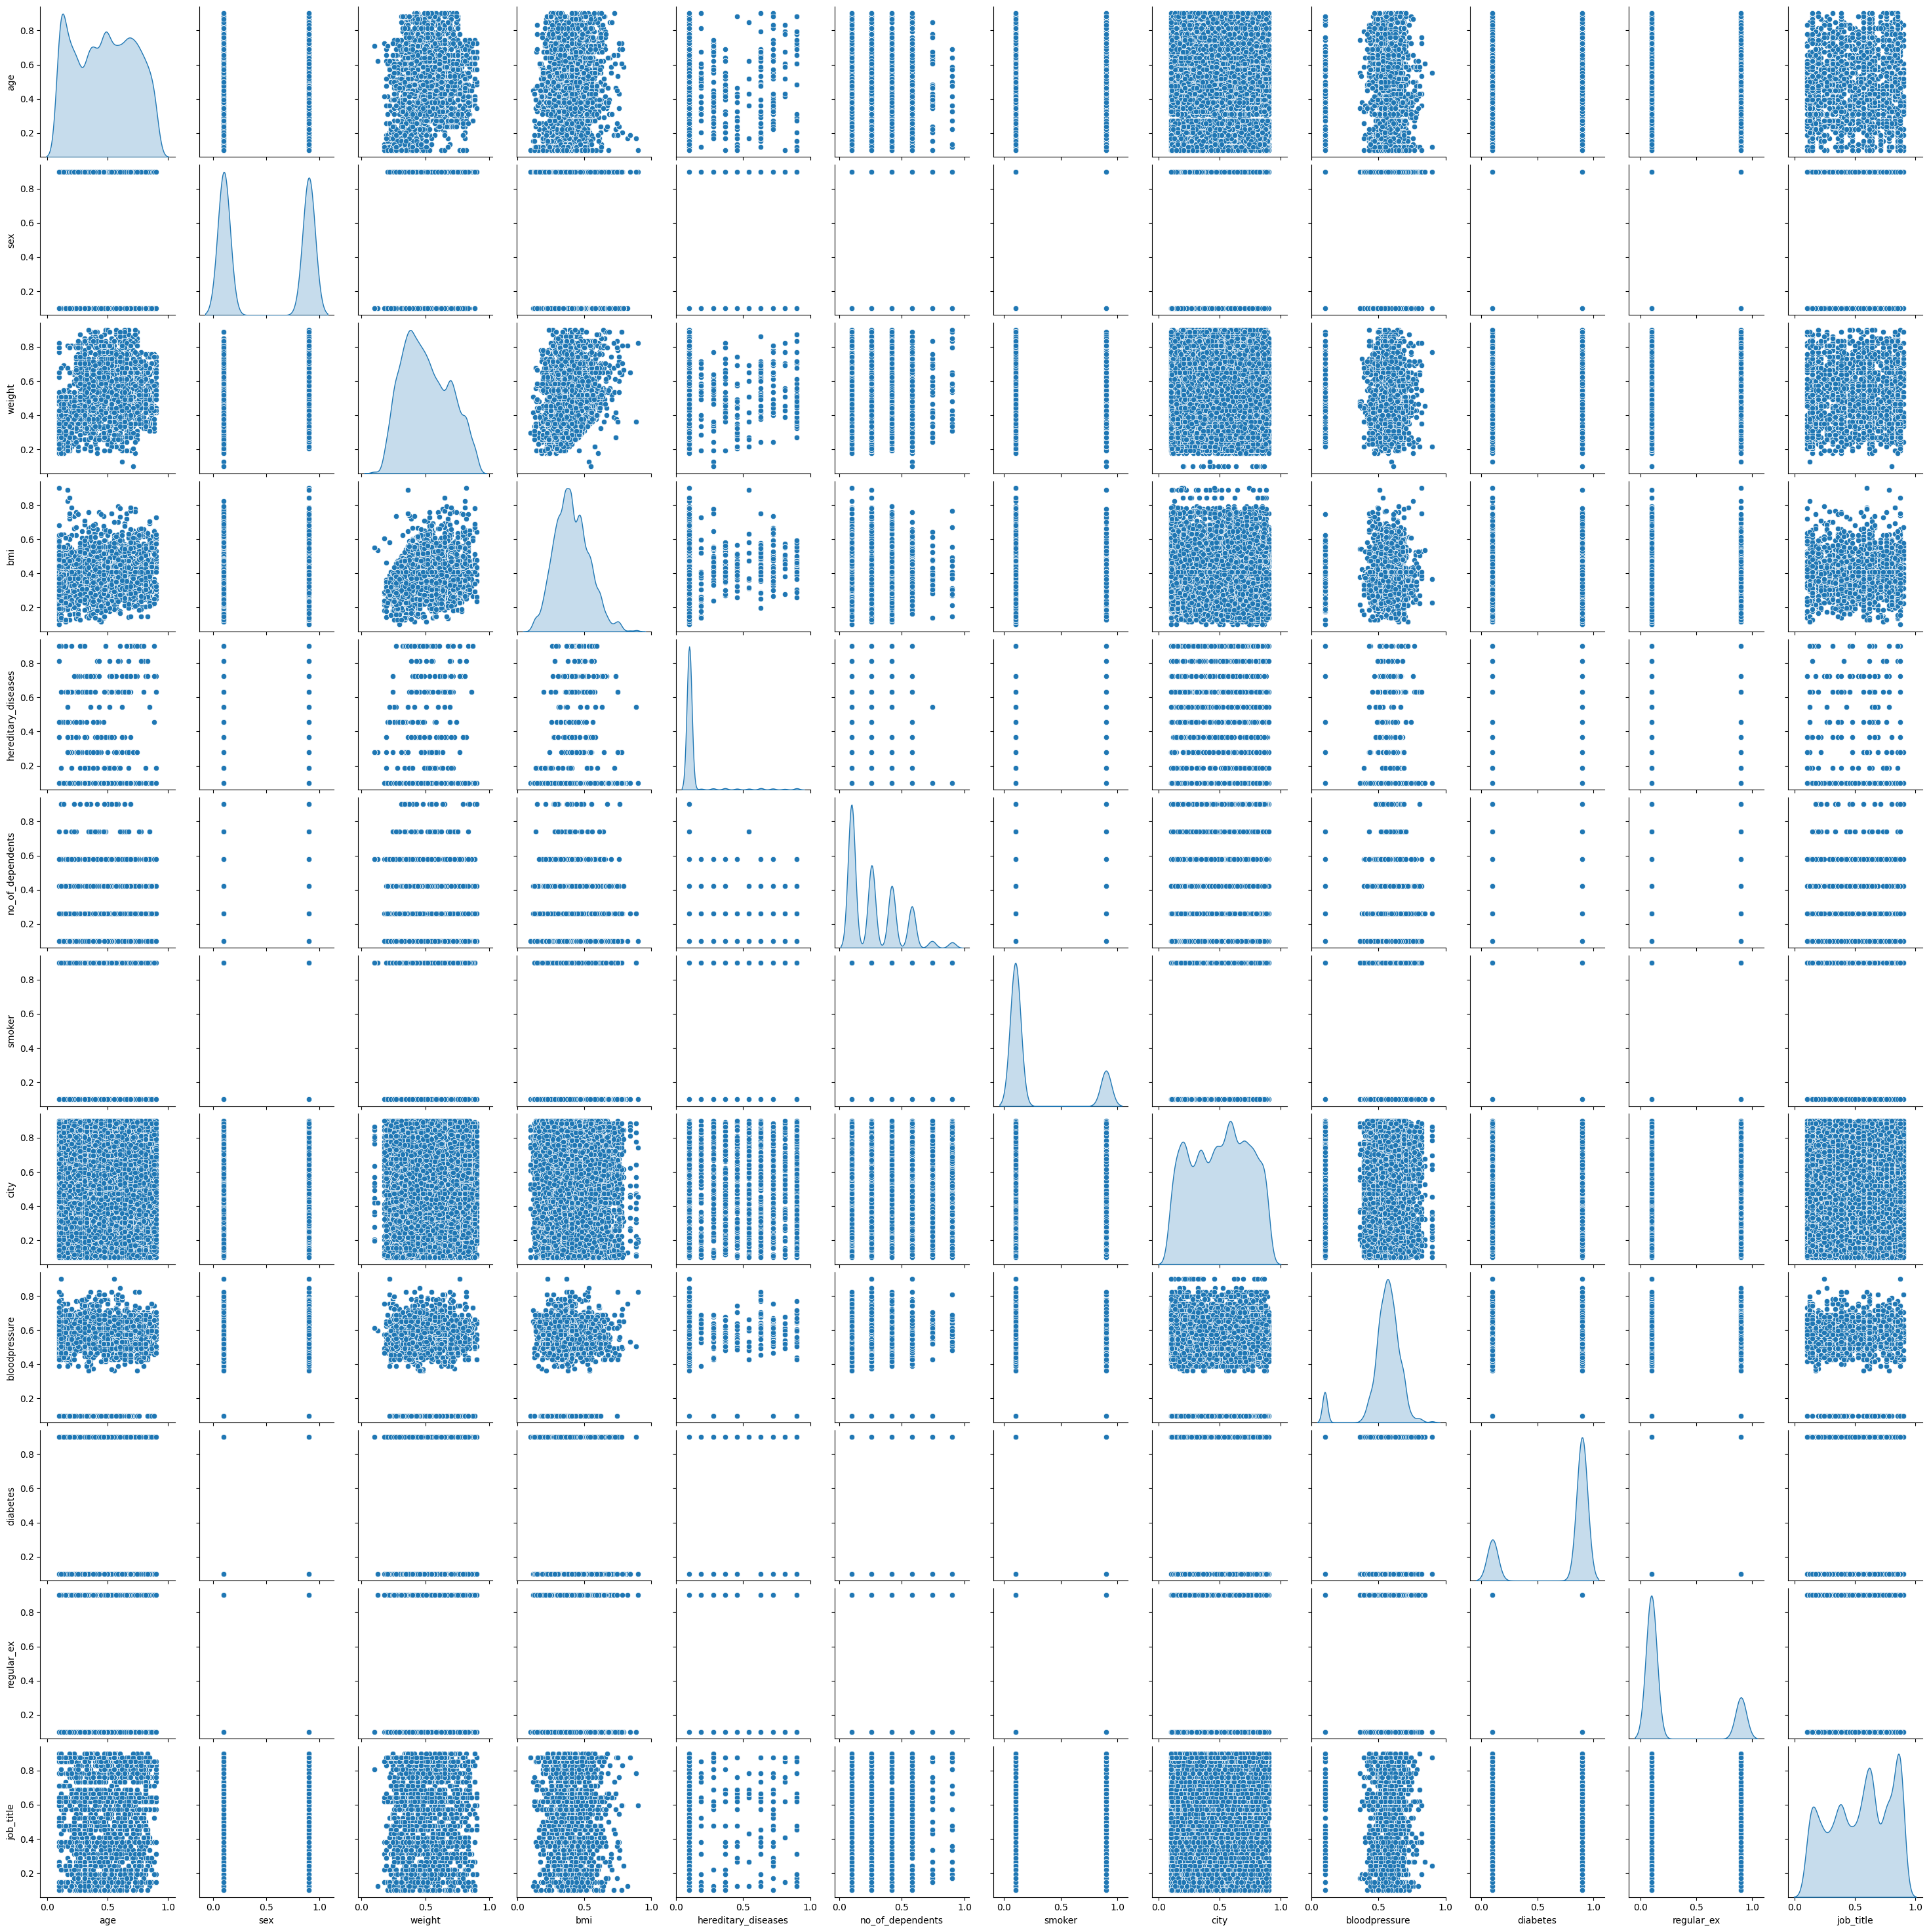

In [18]:
sns.pairplot(Xs[
    Xs.columns
], diag_kind='kde')


<pre>
Correlation Matrix Analysis
    
This heatmap visualizes the Pearson correlation coefficient for all pairs of numerical and encoded categorical features in the dataset.  
The goal is to identify:
Strong Linear Relationships: Identify which features move together (positive correlation) or move in opposite directions (negative correlation).
Multicollinearity: Check for strong correlations between independent variables, which can affect the performance of some machine learning models (e.g., linear regression).
Feature Importance (with respect to 'claim'): Assess how strongly each feature relates to the target variable (claim).
Key Observations: 

Color Scale: The color intensity and hue represent the strength and direction of the correlation coefficient, which ranges from -1 to +1.
Dark Blue (closer to +1.0): Strong Positive correlation.
Light/Cream (closer to 0.0): 
Very Weak or No linear correlation.
Diagonal: The diagonal elements are always darkest blue as a variable is perfectly correlated with itself.
Target Variable (claim):The features showing the strongest positive correlation with the target variable (claim) are smoker (approx 0.77) and military_diseases (approx 0.51). These are likely the most important predictors for the claim amount.

Age, weight, and bmi show moderate positive correlation.
Job_title and regular_ex show a weak negative correlation.
smoker shows a moderate relationship with military_diseases (approx 0.44). This analysis confirms the initial features with the highest predictive power for the claim and identifies potential feature redundancy (weight and bmi) for model simplification
    
</pre>

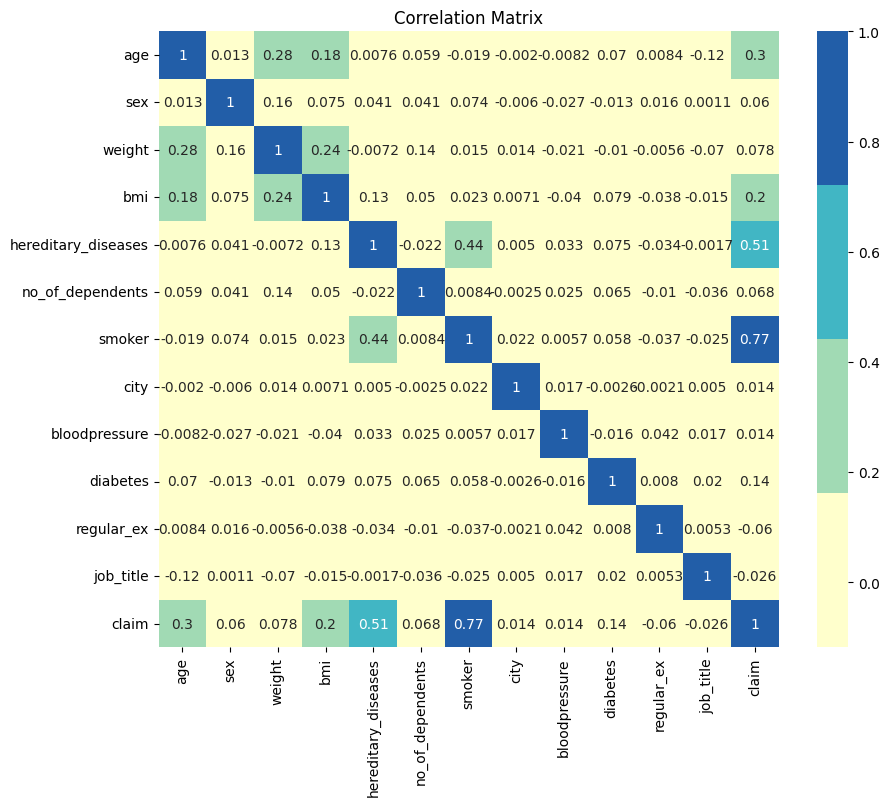

In [19]:
# Create a custom colormap with modified color intensity
custom_cmap = sns.color_palette(['#ffffcc', '#a1dab4', '#41b6c4', '#225ea8'])
correlation_matrix = df.corr()

    # Create a heatmap with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap)
plt.title('Correlation Matrix')
plt.show()

<pre>
Normalizing data to a range like 0.1 to 0.9 (a common variant of min-max scaling) is often preferred in neural networks over the standard 0 to 1 range primarily to avoid saturation of activation functions, especially the sigmoid and tanh functions, in the hidden layers. When input values are very close to 0 or 1 (or -1 and 1 for tanh), the gradient (the slope used for weight updates during backpropagation) can become extremely small, leading to the vanishing gradient problem where weights update very slowly or stop updating altogether. By keeping the normalized data slightly away from the extreme bounds (the "flat" tails) of the sigmoid/tanh functions, you ensure that the gradients remain large enough to facilitate faster and more stable learning throughout the training process.

    
</pre>

In [14]:
scaler = MinMaxScaler(feature_range=(0.1, 0.9))
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Xs = df_scaled.iloc[:, :-1]
ys = df_scaled.iloc[:, -1]

In [15]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.2, random_state=42)

# Part 2: Implementation of BP

<pre>
This part can be found in the python file NeuralNet. This was done using the BP.v2

<---------------
</pre>

# Part 3: Obtaining and comparing predictions using the three models (BP, BP-F, MLR-F)

<pre>
For this part, I have create a helpers files to put there the necessary methods that will be re-used 
for showing the metrics and visualizations. Even for saving these values. Therefore, we can see them at the end 
in a table.
</pre>

In [16]:
X_train = X_train.values
y_train = y_train.values.reshape(-1, 1)

In [18]:
nn_1 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [19]:
nn_1.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006393 - Validation Error: 0.006067
Epoch 100/1000 - Training Error: 0.003438 - Validation Error: 0.003377
Epoch 200/1000 - Training Error: 0.002885 - Validation Error: 0.003036
Epoch 300/1000 - Training Error: 0.002497 - Validation Error: 0.002861
Epoch 400/1000 - Training Error: 0.001990 - Validation Error: 0.002541
Epoch 500/1000 - Training Error: 0.001728 - Validation Error: 0.002369
Epoch 600/1000 - Training Error: 0.001485 - Validation Error: 0.002203
Epoch 700/1000 - Training Error: 0.001414 - Validation Error: 0.002206
Epoch 800/1000 - Training Error: 0.001082 - Validation Error: 0.001897
Epoch 900/1000 - Training Error: 0.001215 - Validation Error: 0.001987


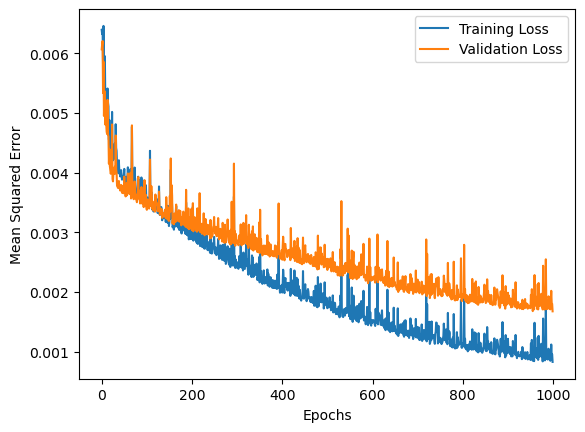

Predictions: [0.19015372 0.08792291 0.15310824 ... 0.23259842 0.13246934 0.17655186]


In [20]:
show_loss(nn_1, X_test)

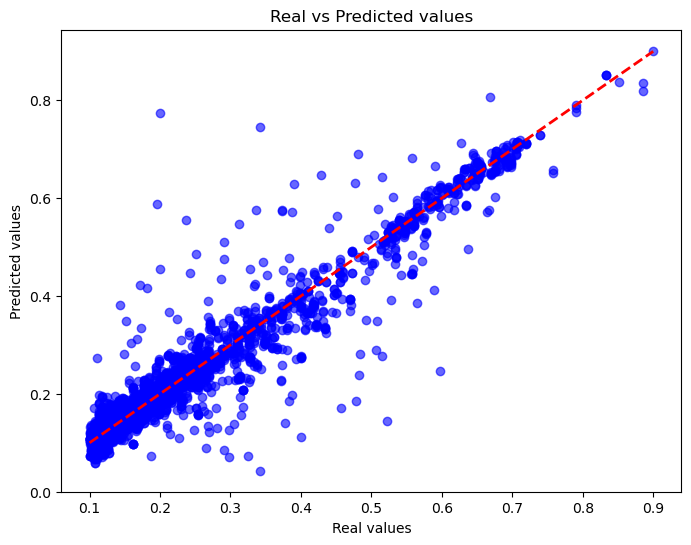

MSE: 0.001923
MAE: 0.024257
MAPE: 0.108752


In [78]:
get_prediction('NN1', nn_1, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [22]:
nn_2 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [23]:
nn_2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006346 - Validation Error: 0.005859
Epoch 100/1000 - Training Error: 0.004300 - Validation Error: 0.004164
Epoch 200/1000 - Training Error: 0.003842 - Validation Error: 0.003701
Epoch 300/1000 - Training Error: 0.004122 - Validation Error: 0.004042
Epoch 400/1000 - Training Error: 0.003657 - Validation Error: 0.003618
Epoch 500/1000 - Training Error: 0.004459 - Validation Error: 0.004538
Epoch 600/1000 - Training Error: 0.004089 - Validation Error: 0.004188
Epoch 700/1000 - Training Error: 0.003005 - Validation Error: 0.003216
Epoch 800/1000 - Training Error: 0.003304 - Validation Error: 0.003552
Epoch 900/1000 - Training Error: 0.002866 - Validation Error: 0.003172


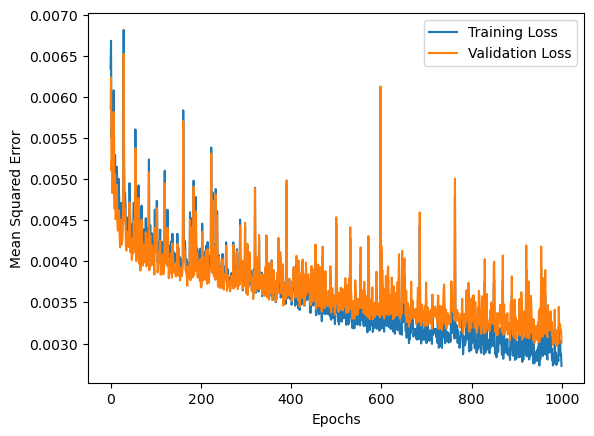

Predictions: [0.22837103 0.07200959 0.19488808 ... 0.21957629 0.19171791 0.20092752]


In [24]:
show_loss(nn_2, X_test)

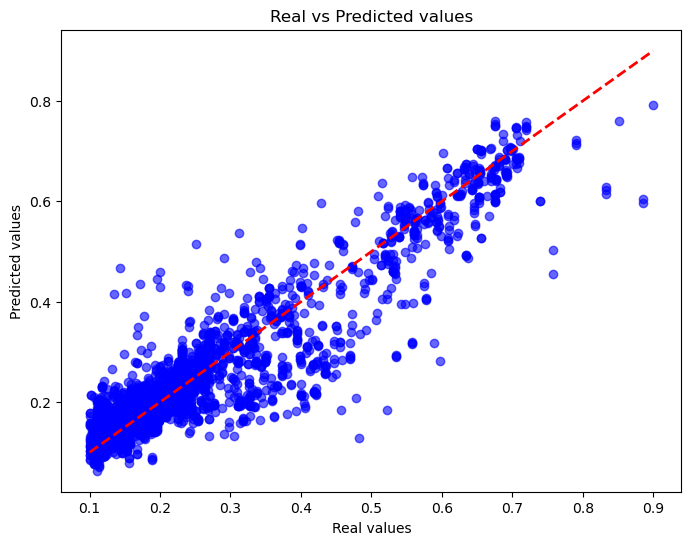

MSE: 0.003337
MAE: 0.038251
MAPE: 0.166587


In [77]:
get_prediction('NN2', nn_2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [26]:
nn_3 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='sigmoid',
    validation_split=0.2
)

In [27]:
nn_3.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.024613 - Validation Error: 0.023433
Epoch 100/1000 - Training Error: 0.005615 - Validation Error: 0.005681
Epoch 200/1000 - Training Error: 0.005543 - Validation Error: 0.005645
Epoch 300/1000 - Training Error: 0.005434 - Validation Error: 0.005443
Epoch 400/1000 - Training Error: 0.005284 - Validation Error: 0.005347
Epoch 500/1000 - Training Error: 0.005111 - Validation Error: 0.005136
Epoch 600/1000 - Training Error: 0.005002 - Validation Error: 0.004962
Epoch 700/1000 - Training Error: 0.004807 - Validation Error: 0.004782
Epoch 800/1000 - Training Error: 0.004693 - Validation Error: 0.004645
Epoch 900/1000 - Training Error: 0.004579 - Validation Error: 0.004541


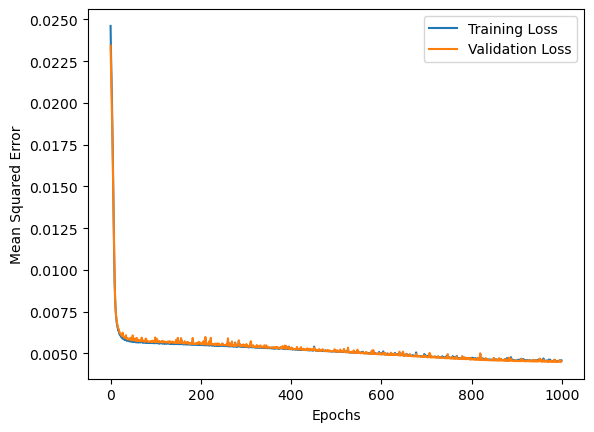

Predictions: [0.2174678  0.11819455 0.16989595 ... 0.24174719 0.13184821 0.17552026]


In [28]:
show_loss(nn_3, X_test)

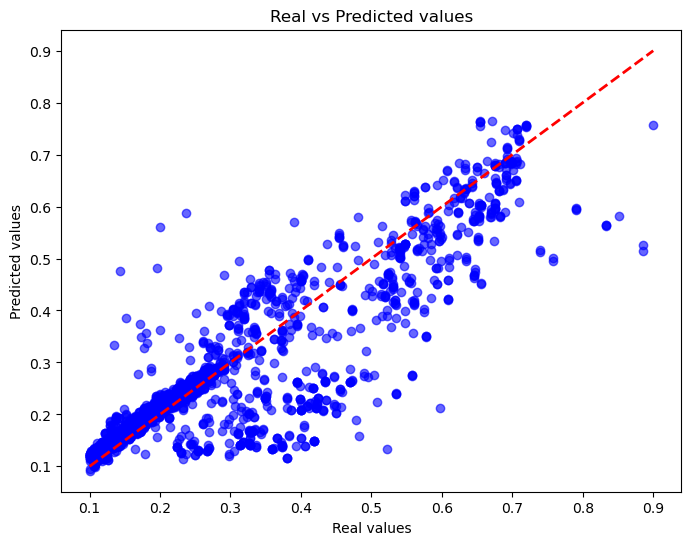

MSE: 0.00461
MAE: 0.038366
MAPE: 0.136292


In [76]:
get_prediction('NN3', nn_3, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [30]:
nn_4 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='linear',
    validation_split=0.2
)

In [31]:
nn_4.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.008363 - Validation Error: 0.008923
Epoch 100/1000 - Training Error: 0.006180 - Validation Error: 0.006411
Epoch 200/1000 - Training Error: 0.006169 - Validation Error: 0.006499
Epoch 300/1000 - Training Error: 0.006084 - Validation Error: 0.006536
Epoch 400/1000 - Training Error: 0.006148 - Validation Error: 0.006488
Epoch 500/1000 - Training Error: 0.006003 - Validation Error: 0.006410
Epoch 600/1000 - Training Error: 0.006029 - Validation Error: 0.006427
Epoch 700/1000 - Training Error: 0.006003 - Validation Error: 0.006373
Epoch 800/1000 - Training Error: 0.006010 - Validation Error: 0.006342
Epoch 900/1000 - Training Error: 0.005986 - Validation Error: 0.006411


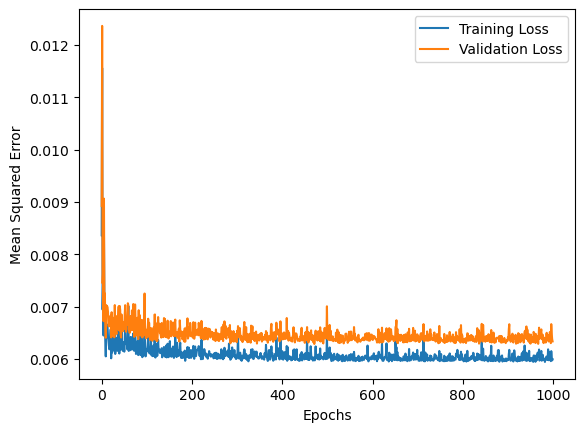

Predictions: [0.25726489 0.10256772 0.18173388 ... 0.25046186 0.1388985  0.18155541]


In [32]:
show_loss(nn_4, X_test)

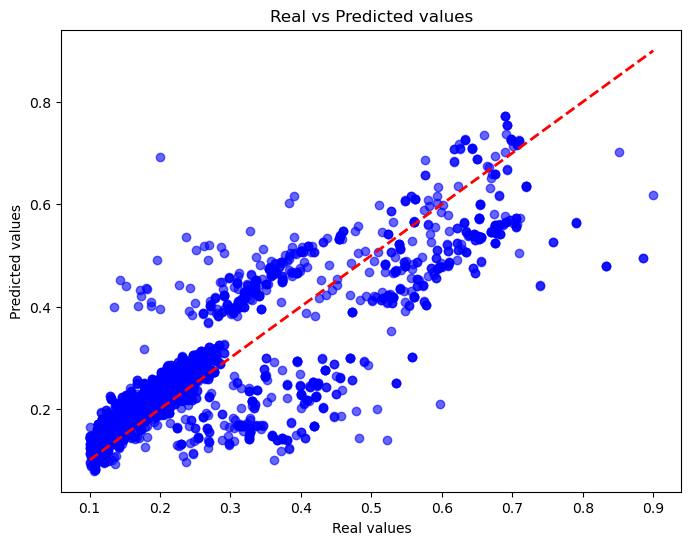

MSE: 0.00617
MAE: 0.054588
MAPE: 0.210353


In [75]:
get_prediction('NN4', nn_4, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [34]:
nn_5 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [35]:
nn_5.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.005339 - Validation Error: 0.005000
Epoch 100/1000 - Training Error: 0.003014 - Validation Error: 0.003369
Epoch 200/1000 - Training Error: 0.002292 - Validation Error: 0.002885
Epoch 300/1000 - Training Error: 0.002287 - Validation Error: 0.002818
Epoch 400/1000 - Training Error: 0.001738 - Validation Error: 0.002271
Epoch 500/1000 - Training Error: 0.001493 - Validation Error: 0.002082
Epoch 600/1000 - Training Error: 0.001551 - Validation Error: 0.002205
Epoch 700/1000 - Training Error: 0.001920 - Validation Error: 0.002604
Epoch 800/1000 - Training Error: 0.001323 - Validation Error: 0.002012
Epoch 900/1000 - Training Error: 0.001344 - Validation Error: 0.002036


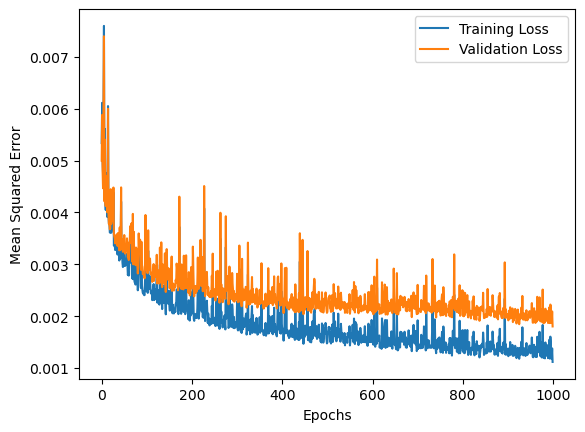

Predictions: [0.20751004 0.13473245 0.15120025 ... 0.22493829 0.13512327 0.15534401]


In [36]:
show_loss(nn_5, X_test)

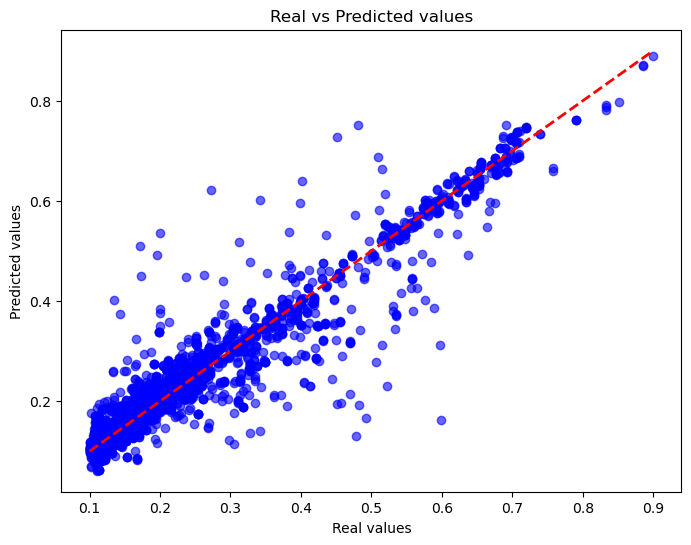

MSE: 0.002053
MAE: 0.026375
MAPE: 0.118226


In [74]:
get_prediction('NN5', nn_5, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [38]:
nn_6 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [39]:
nn_6.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.008026 - Validation Error: 0.008179
Epoch 100/1000 - Training Error: 0.003943 - Validation Error: 0.004385
Epoch 200/1000 - Training Error: 0.004119 - Validation Error: 0.004567
Epoch 300/1000 - Training Error: 0.003779 - Validation Error: 0.004318
Epoch 400/1000 - Training Error: 0.003489 - Validation Error: 0.004029
Epoch 500/1000 - Training Error: 0.003191 - Validation Error: 0.003822
Epoch 600/1000 - Training Error: 0.003257 - Validation Error: 0.003879
Epoch 700/1000 - Training Error: 0.002681 - Validation Error: 0.003312
Epoch 800/1000 - Training Error: 0.002492 - Validation Error: 0.003264
Epoch 900/1000 - Training Error: 0.002997 - Validation Error: 0.003816


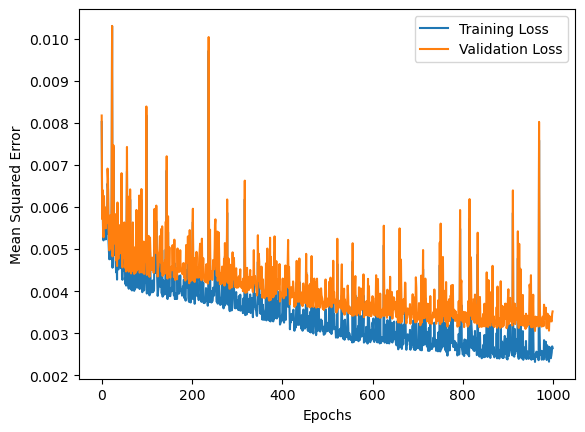

Predictions: [0.20575209 0.08317247 0.14721389 ... 0.19501728 0.13061474 0.18381638]


In [40]:
show_loss(nn_6, X_test)

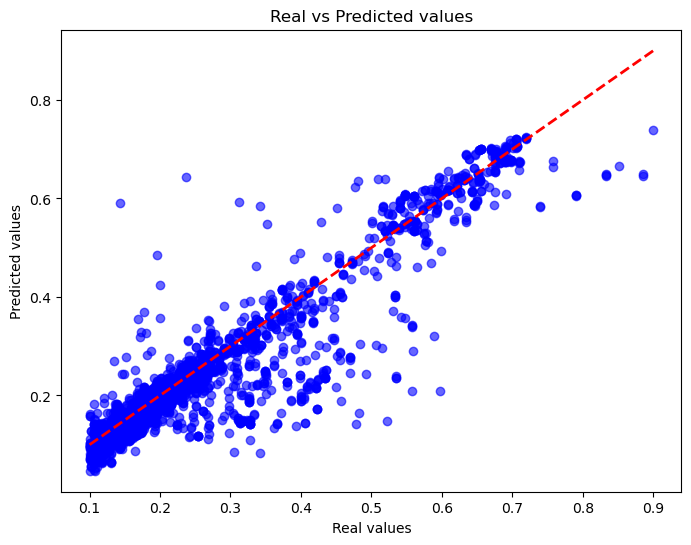

MSE: 0.003176
MAE: 0.031766
MAPE: 0.129258


In [73]:
get_prediction('NN6', nn_6, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [42]:
nn_7 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='sigmoid',
    validation_split=0.2
)

In [43]:
nn_7.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.014169 - Validation Error: 0.014021
Epoch 100/1000 - Training Error: 0.004499 - Validation Error: 0.004979
Epoch 200/1000 - Training Error: 0.004360 - Validation Error: 0.004857
Epoch 300/1000 - Training Error: 0.004278 - Validation Error: 0.004806
Epoch 400/1000 - Training Error: 0.004127 - Validation Error: 0.004579
Epoch 500/1000 - Training Error: 0.003960 - Validation Error: 0.004485
Epoch 600/1000 - Training Error: 0.003893 - Validation Error: 0.004465
Epoch 700/1000 - Training Error: 0.003920 - Validation Error: 0.004456
Epoch 800/1000 - Training Error: 0.003858 - Validation Error: 0.004385
Epoch 900/1000 - Training Error: 0.003775 - Validation Error: 0.004342


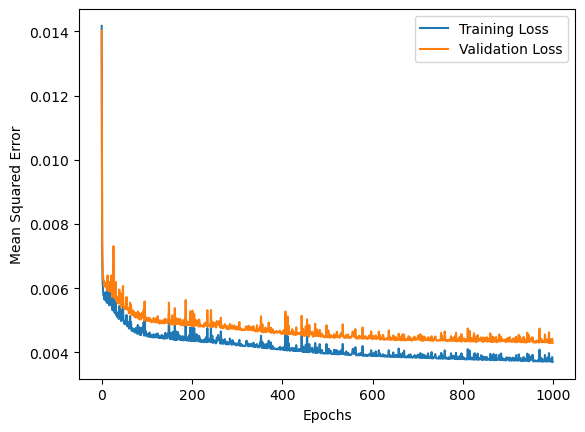

Predictions: [0.22961956 0.1329451  0.19109869 ... 0.21550541 0.13899165 0.17973724]


In [44]:
show_loss(nn_7, X_test)

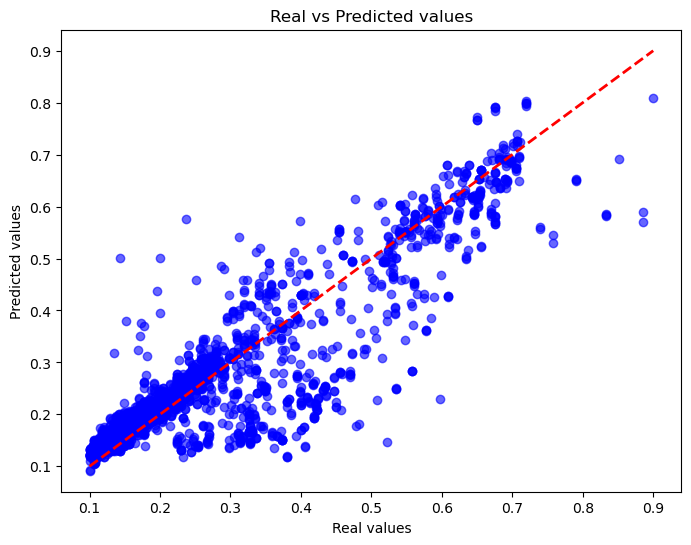

MSE: 0.004134
MAE: 0.039257
MAPE: 0.153349


In [72]:
get_prediction('NN7', nn_7, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [46]:
nn_8 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='linear',
    validation_split=0.2
)

In [47]:
nn_8.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.007402 - Validation Error: 0.007424
Epoch 100/1000 - Training Error: 0.007758 - Validation Error: 0.007830
Epoch 200/1000 - Training Error: 0.006159 - Validation Error: 0.006034
Epoch 300/1000 - Training Error: 0.006318 - Validation Error: 0.006213
Epoch 400/1000 - Training Error: 0.009084 - Validation Error: 0.009252
Epoch 500/1000 - Training Error: 0.006611 - Validation Error: 0.006394
Epoch 600/1000 - Training Error: 0.007386 - Validation Error: 0.007155
Epoch 700/1000 - Training Error: 0.006896 - Validation Error: 0.006672
Epoch 800/1000 - Training Error: 0.006234 - Validation Error: 0.006165
Epoch 900/1000 - Training Error: 0.006138 - Validation Error: 0.005980


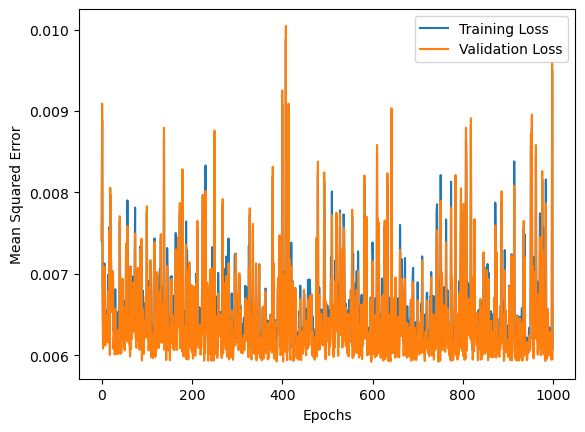

Predictions: [0.24443638 0.10013379 0.17471616 ... 0.24828585 0.13568762 0.18469255]


In [48]:
show_loss(nn_8, X_test)

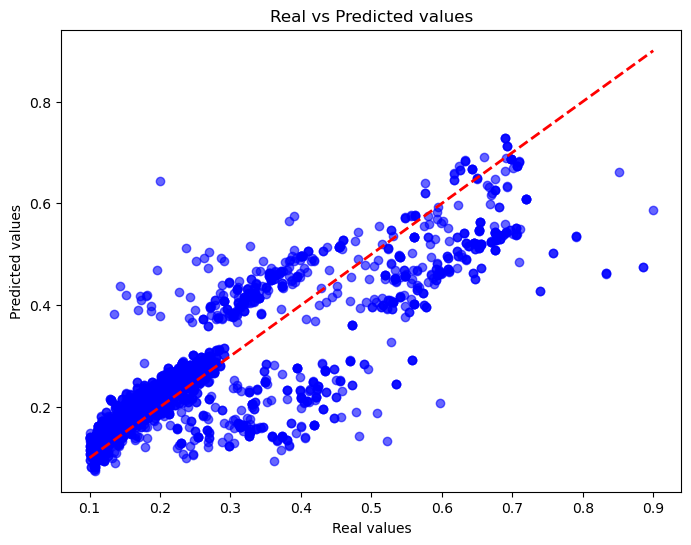

MSE: 0.006157
MAE: 0.051763
MAPE: 0.190623


In [71]:
get_prediction('NN8', nn_8, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [50]:
nn_9 = NeuralNet(
    layers=[X_train.shape[1], 256, 128, 1],
    epochs=1200,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [51]:
nn_9.fit(X_train, y_train)

Epoch 0/1200 - Training Error: 0.005551 - Validation Error: 0.006182
Epoch 100/1200 - Training Error: 0.002482 - Validation Error: 0.003475
Epoch 200/1200 - Training Error: 0.001720 - Validation Error: 0.002859
Epoch 300/1200 - Training Error: 0.001478 - Validation Error: 0.002653
Epoch 400/1200 - Training Error: 0.001109 - Validation Error: 0.002365
Epoch 500/1200 - Training Error: 0.000999 - Validation Error: 0.002339
Epoch 600/1200 - Training Error: 0.000871 - Validation Error: 0.002219
Epoch 700/1200 - Training Error: 0.000409 - Validation Error: 0.001835
Epoch 800/1200 - Training Error: 0.000268 - Validation Error: 0.001679
Epoch 900/1200 - Training Error: 0.000205 - Validation Error: 0.001629
Epoch 1000/1200 - Training Error: 0.000200 - Validation Error: 0.001616
Epoch 1100/1200 - Training Error: 0.000222 - Validation Error: 0.001682


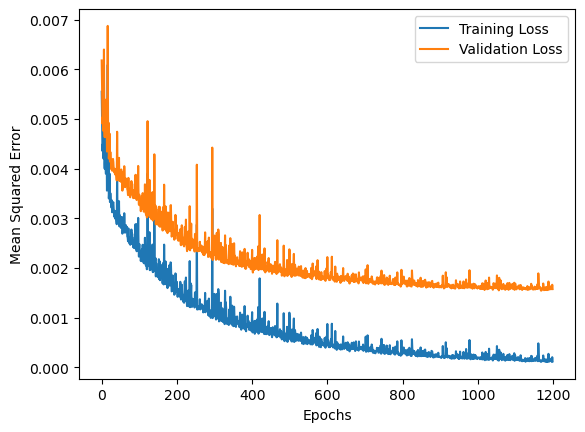

Predictions: [0.1979564  0.09151766 0.14509683 ... 0.23056272 0.11581999 0.16483272]


In [52]:
show_loss(nn_9, X_test)

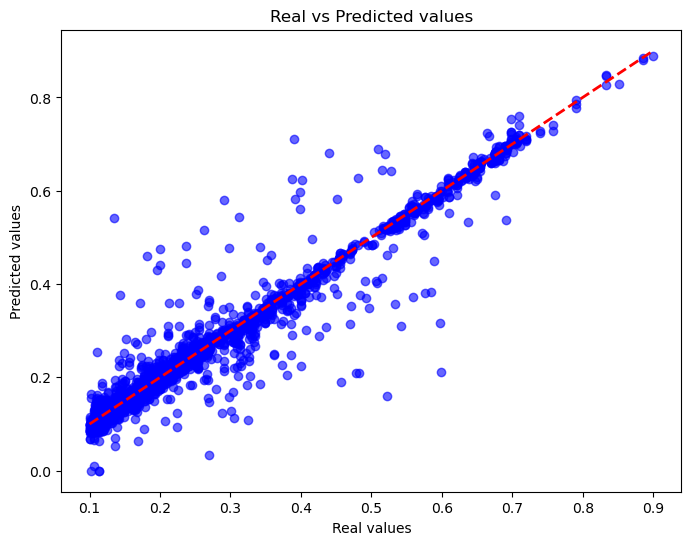

MSE: 0.001343
MAE: 0.016273
MAPE: 0.073888


In [70]:
get_prediction('NN9', nn_9, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [54]:
nn_10 = NeuralNet(
    layers=[X_train.shape[1], 256, 128, 1],
    epochs=1200,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [55]:
nn_10.fit(X_train, y_train)

Epoch 0/1200 - Training Error: 0.008882 - Validation Error: 0.008575
Epoch 100/1200 - Training Error: 0.004117 - Validation Error: 0.004215
Epoch 200/1200 - Training Error: 0.003724 - Validation Error: 0.004020
Epoch 300/1200 - Training Error: 0.003469 - Validation Error: 0.003743
Epoch 400/1200 - Training Error: 0.003421 - Validation Error: 0.003507
Epoch 500/1200 - Training Error: 0.002976 - Validation Error: 0.003416
Epoch 600/1200 - Training Error: 0.003068 - Validation Error: 0.003664
Epoch 700/1200 - Training Error: 0.002742 - Validation Error: 0.003181
Epoch 800/1200 - Training Error: 0.002419 - Validation Error: 0.002903
Epoch 900/1200 - Training Error: 0.002722 - Validation Error: 0.003215
Epoch 1000/1200 - Training Error: 0.002283 - Validation Error: 0.002775
Epoch 1100/1200 - Training Error: 0.002257 - Validation Error: 0.002908


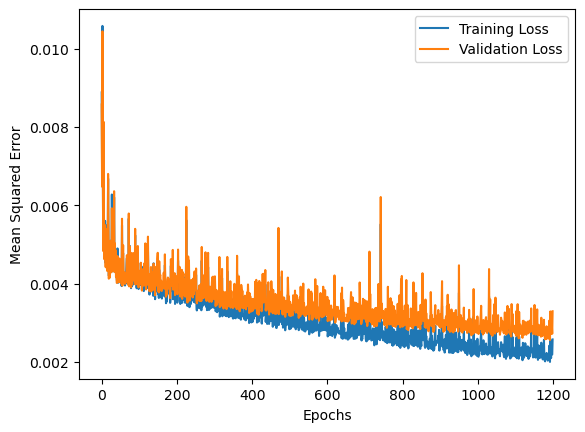

Predictions: [0.20651667 0.11739627 0.17232012 ... 0.27660673 0.22703949 0.19563884]


In [56]:
show_loss(nn_10, X_test)

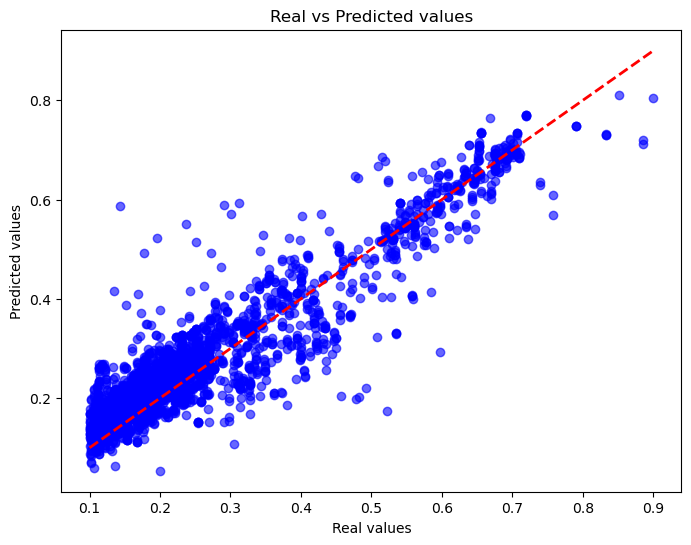

MSE: 0.003353
MAE: 0.042451
MAPE: 0.208848


In [69]:
get_prediction('NN10', nn_10, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [79]:
save_prediction_to_csv("hyperparamether_comparison.csv", metrics)

In [80]:
parameters = {
    'NN1': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN2': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
    'NN3': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'sigmoid',
    },
    'NN4': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'linear',
    },
    'NN5': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN6': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
    'NN7': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'sigmoid',
    },
    'NN8': { 
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'linear',
    },
    'NN9': {
        'number_of_layers': sum([X_train.shape[1], 256, 128, 1]),
        'layer_structure': [X_train.shape[1], 256, 128, 1],
        'num_epochs': 1200,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN10': {
        'number_of_layers': sum([X_train.shape[1], 256, 128, 1]),
        'layer_structure': [X_train.shape[1], 256, 128, 1],
        'num_epochs': 1200,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
}

## The best results that we got are NN9, NN1, NN5

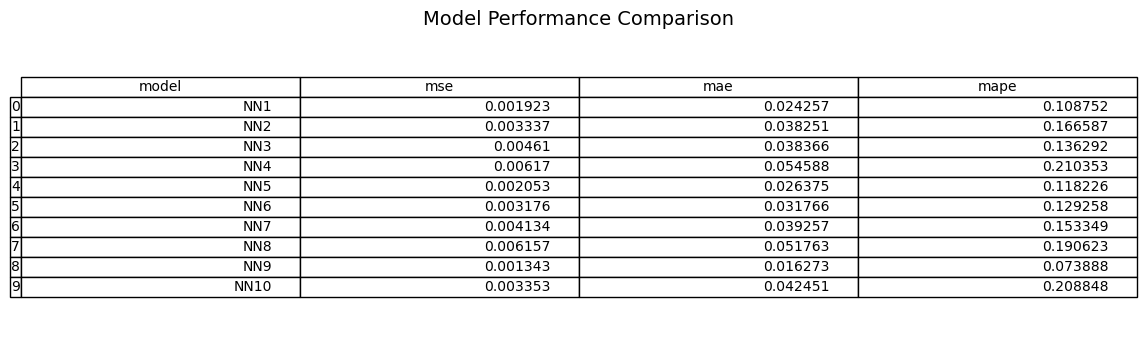

In [81]:
# Read CSV
df = pd.read_csv("hyperparamether_comparison.csv")  # change path to your CSV
# If you want to transpose like your example (optional)
#df = df.T  ## Models = rows, metrics = columns (only if needed)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

In [154]:
def compare_three_nn_performance_individual_loss(nn_models, X_test, y_test, model_names, only_real_vs_prediction=False):
    
    # --- 1. Determine Layout ---
    nrows = 1
    ncols = 3
    
    # Use 2 rows only if we need to plot the loss curves
    if not only_real_vs_prediction:
        nrows = 2
        # figsize is adjusted for better aspect ratio when only 1 row is used
        figsize_h = 10 
        suptitle_text = 'Comprehensive Model Comparison (Individual Loss & Prediction Scatter)'
    else:
        figsize_h = 5 
        suptitle_text = 'Model Comparison (Real vs. Predicted Scatter Only)'

    # 2. Create the figure and subplots
    # The axes variable will be an array (1D for 1 row, 2D for 2 rows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, figsize_h))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Determine the global data range for consistent scatter plot axes
    min_val = y_test.min() * 0.95
    max_val = y_test.max() * 1.05

    
    for i, (nn, name) in enumerate(zip(nn_models, model_names)):
        
        # Get predictions for the scatter plot
        y_pred = nn.predict(X_test.values)
        
        # --- Top Row: Individual Loss Plot (ax_loss) ---
        if not only_real_vs_prediction:
            
            # Get loss data for the loss plot (only needed if plotting loss)
            try:
                # Assuming nn.loss_epochs() returns (train_loss, val_loss)
                train_loss, val_loss = nn.loss_epochs()
            except AttributeError:
                print(f"Warning: Model {name} does not have a loss_epochs() method. Using placeholder.")
                train_loss, val_loss = np.zeros(10), np.zeros(10) # Placeholder

            ax_loss = axes[0, i]
            ax_loss.plot(train_loss, label='Training Loss', color='blue')
            ax_loss.plot(val_loss, label='Validation Loss', color='red', linestyle='--')
            
            ax_loss.set_xlabel('Epochs')
            ax_loss.set_ylabel('Mean Squared Error')
            ax_loss.set_title(f'{name} Loss Curves')
            ax_loss.legend()
            ax_loss.grid(True, linestyle=':')
            
            # Scatter plot is in the bottom row
            ax_scatter = axes[1, i]
            
        else:
            # If only 1 row, axes is 1D. Scatter plot is in the only row.
            ax_scatter = axes[i]
            
        # --- Scatter Plot Logic ---
        # Plot the scatter plot
        ax_scatter.scatter(y_test, y_pred, alpha=0.6, label='Predictions')
        
        # Plot the perfect prediction line (y=x)
        ax_scatter.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
        
        # Set axis limits and labels for consistency
        ax_scatter.set_xlim(min_val, max_val)
        ax_scatter.set_ylim(min_val, max_val)
        ax_scatter.set_xlabel('Real values')
        # Only label the Y-axis on the first plot in the row to save space
        if i == 0 or not only_real_vs_prediction:
             ax_scatter.set_ylabel('Predicted values')

        ax_scatter.set_title(f'{name} Predictions')
        
    
    plt.suptitle(suptitle_text, fontsize=18)
    plt.show()

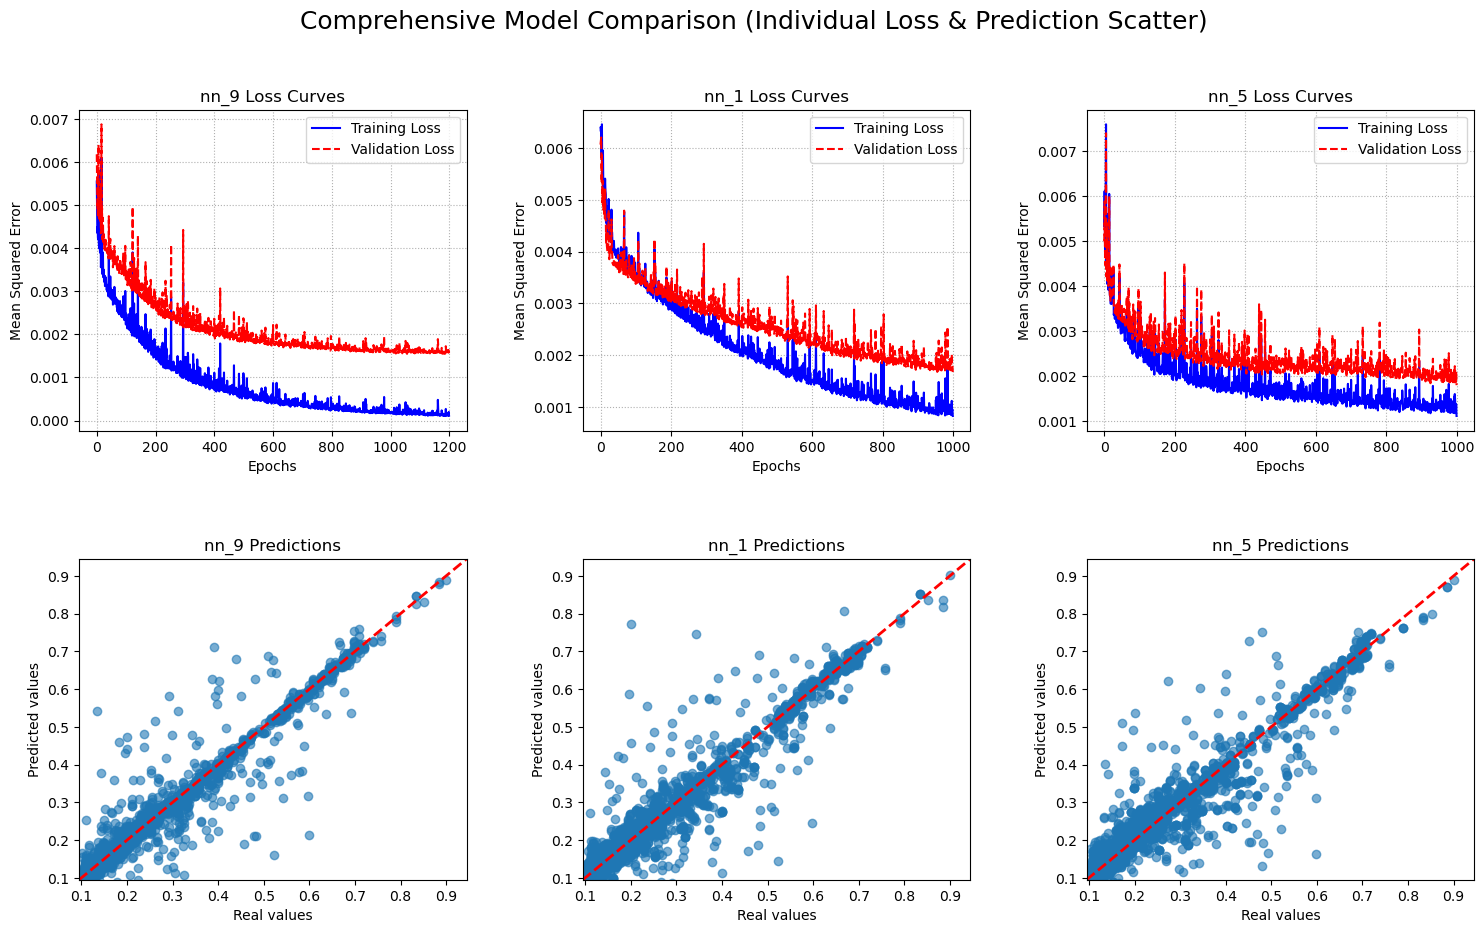

In [155]:
compare_three_nn_performance_individual_loss([nn_9, nn_1, nn_5], X_test, y_test, ['nn_9', 'nn_1', 'nn_5'])

In [89]:
# your main df (the one shown in the table)
# df_main = ...

# 1) Convert dict -> DF with model names as index
df_params = pd.DataFrame.from_dict(parameters, orient="index")

# (optional) if you want the model name as a column later
df_params.index.name = "model"

# 2) Reindex df_params to match the exact order (and duplicates) in df_main['model']
#    Use .values to pass a list of labels; reindex will duplicate rows when labels repeat.
df_params_aligned = df_params.reindex(df["model"].values)

# 3) Reset index so both dataframes have a simple 0..N-1 index before concatenation
#    (This also removes the model name from the index; model column remains in df_main)
df_params_aligned = df_params_aligned.reset_index(drop=True)
df_main_reset = df.reset_index(drop=True)

# 4) Concatenate side-by-side
df_final = pd.concat([df_main_reset, df_params_aligned], axis=1)

# 5) (Optional) if you want to check if any models were missing from the dict:
missing = set(df["model"].unique()) - set(df_params.index)
if missing:
    print("Missing parameter entries for models:", missing)

df_final

,model,mse,mae,mape,number_of_layers,layer_structure,num_epochs,learning_rate,momentum,activation_function
0,NN1,0.001923,0.024257,0.108752,141,"[12, 64, 64, 1]",1000,0.001,0.9,relu
1,NN2,0.003337,0.038251,0.166587,141,"[12, 64, 64, 1]",1000,0.001,0.9,tanh
2,NN3,0.004610,0.038366,0.136292,141,"[12, 64, 64, 1]",1000,0.001,0.9,sigmoid
3,NN4,0.006170,0.054588,0.210353,141,"[12, 64, 64, 1]",1000,0.001,0.9,linear
4,NN5,0.002053,0.026375,0.118226,77,"[12, 32, 32, 1]",1000,0.010,0.9,relu
5,NN6,0.003176,0.031766,0.129258,77,"[12, 32, 32, 1]",1000,0.010,0.9,tanh
6,NN7,0.004134,0.039257,0.153349,77,"[12, 32, 32, 1]",1000,0.010,0.9,sigmoid
7,NN8,0.006157,0.051763,0.190623,77,"[12, 32, 32, 1]",1000,0.010,0.9,linear
8,NN9,0.001343,0.016273,0.073888,397,"[12, 256, 128, 1]",1200,0.001,0.9,relu
9,NN10,0.003353,0.042451,0.208848,397,"[12, 256, 128, 1]",1200,0.001,0.9,tanh


<pre>
A review/discussion of 2-3 paragraphs of why you think these parameters are
the most adequate.
    
Based on the different attempts in the table and checking the different hyperparamether.
Model NN9 demonstrates the best set of hyperparameters, achieving superior performance across all evaluation metrics: 
    MSE (0.001343)
    MAE (0.016273)
    MAPE (0.073888) 
The architecture is defined by 397 layers with the structure [12,256,128,1], which is significantly deeper and wider than the other networks (NN1-NN8), Keep in mind that for regression problems, it's better to use at least two hidden layers. Otherwise, the model may get overfitted. Providing the necessary representational power to capture the different variables, and non-linear relationships within the dataset. Furthermore, the use of relu activation function is crucial, as it is computationally efficient and effectively prevents the vanishing gradient problem that can plague the training of deeper networks, allowing the model to fully utilize its large capacity.

The successful performance of NN9 is also heavily dependent on its training parameters. A relatively low Learning Rate (0.001) was chosen, which ensures that the gradient descent steps are small and cautious. This minimizes the risk of overshooting the global minimum and allows the model to find a more precise and generalized solution. To compensate for the slow learning rate, the number of epochs was increased to 1200. This provides the model with sufficient iterations to get better resulst, extracting maximum value from the small weight updates. This precise convergence is further stabilized by the high Momentum (0.9), which accelerates training in consistent directions and decreases oscillations, resulting in a more efficient path to the optimal parameter set. The combination of high network capacity, robust activation, and conservative-yet-thorough training is what sets NN9 apart, leading to its lowest error metrics compared to the simpler or differently trained models.
    
</pre>    

# Part 3.2: Model result comparison

### Linear Regression Model

In [119]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


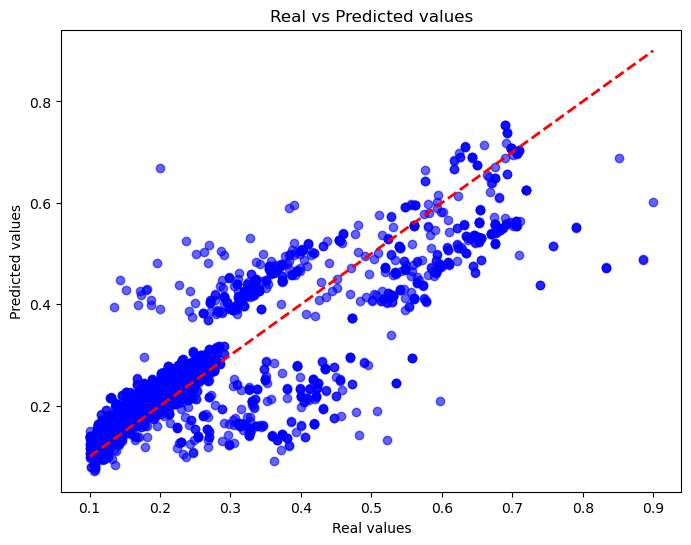

MSE: 0.006111
MAE: 0.051995
MAPE: 0.193898


In [91]:
get_prediction('LinearRegression', model_linear, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

### NN with Tensorflow

In [92]:
shape = X_train.shape[1]
shape

12

In [93]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(shape, name="InputLayer"))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n1'))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n2'))
model.add(tf.keras.layers.Dense(1, name='Output'))

model.compile(
    optimizer = 'rmsprop',
    loss = 'mse',
    metrics = ['mae', 'mse', 'mape']
)

In [94]:
batch_size = 16
epochs = 50
seed = 123
fit_verbosity = 1

In [95]:
history = model.fit(
    X_train,
    y_train,
    epochs          = epochs,
    batch_size      = batch_size,
    verbose         = fit_verbosity,
    validation_data = (X_test, y_test)
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - loss: 0.0076 - mae: 0.0587 - mape: 23.1907 - mse: 0.0076 - val_loss: 0.0052 - val_mae: 0.0447 - val_mape: 16.1541 - val_mse: 0.0052
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 0.0051 - mae: 0.0480 - mape: 19.0671 - mse: 0.0051 - val_loss: 0.0046 - val_mae: 0.0468 - val_mape: 19.4448 - val_mse: 0.0046
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 0.0047 - mae: 0.0447 - mape: 17.6874 - mse: 0.0047 - val_loss: 0.0044 - val_mae: 0.0487 - val_mape: 20.8848 - val_mse: 0.0044
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - loss: 0.0044 - mae: 0.0429 - mape: 17.1052 - mse: 0.0044 - val_loss: 0.0042 - val_mae: 0.0421 - val_mape: 17.6742 - val_mse: 0.0042
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 0.0042 - mae: 0.0415 - mape: 16.5940 - mse: 0.0042 - val_loss: 0.0040 - val_mae: 0.0391 - val_mape: 15.3740 - val_mse: 0.0040
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss

Text(0.5, 0, 'epochs')

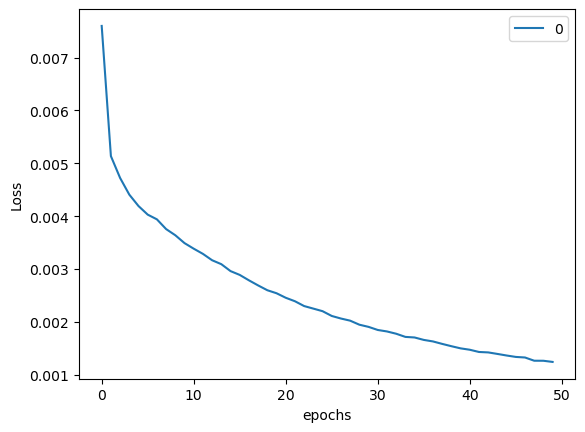

In [97]:
pd.DataFrame(history.history['loss']).plot()
plt.ylabel("Loss")
plt.xlabel("epochs")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step


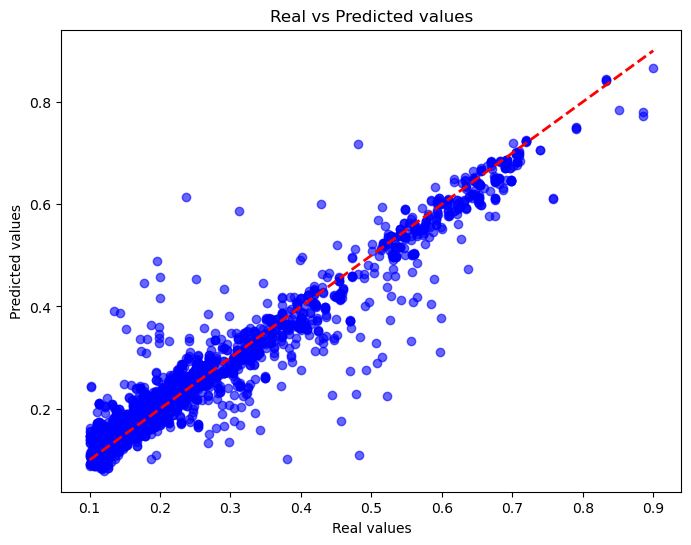

MSE: 0.001553
MAE: 0.023435
MAPE: 0.108057


In [156]:
get_prediction('NN with tensorflow' ,model, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [109]:
metrics2 = {}
metrics2['LinearRegression'] = metrics['LinearRegression']
metrics2['NN with tensorflow'] = metrics['NN with tensorflow']

In [110]:
metrics2

{'LinearRegression': {'mse': 0.006111, 'mae': 0.051995, 'mape': 0.193898},
 'NN with tensorflow': {'mse': 0.001553, 'mae': 0.023435, 'mape': 0.108057}}

In [111]:
save_prediction_to_csv("comparison_with_libraries.csv", metrics2)

In [112]:
df_2 = pd.read_csv("hyperparamether_comparison.csv") 

In [113]:
new_df = df_2.iloc[[8, 0, 4]]

In [114]:
new_df

,model,mse,mae,mape
8,NN9,0.001343,0.016273,0.073888
0,NN1,0.001923,0.024257,0.108752
4,NN5,0.002053,0.026375,0.118226


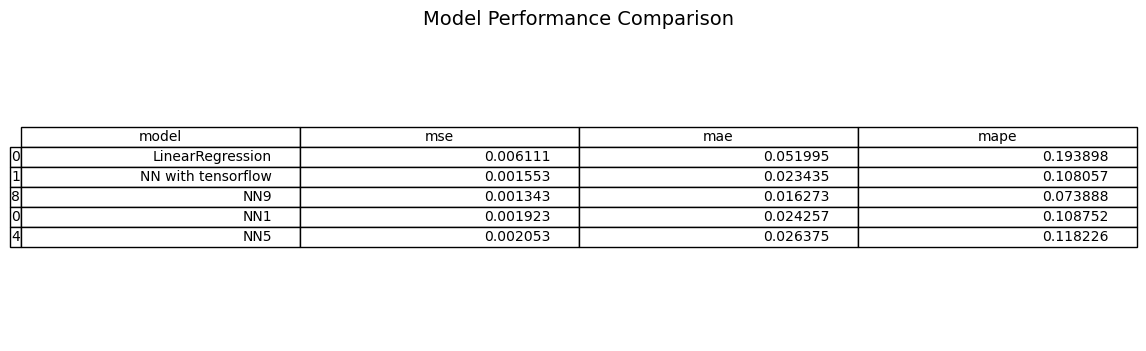

In [115]:
df = pd.read_csv("comparison_with_libraries.csv")  # change path to your CSV
df = pd.concat([df, new_df], axis=0)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step


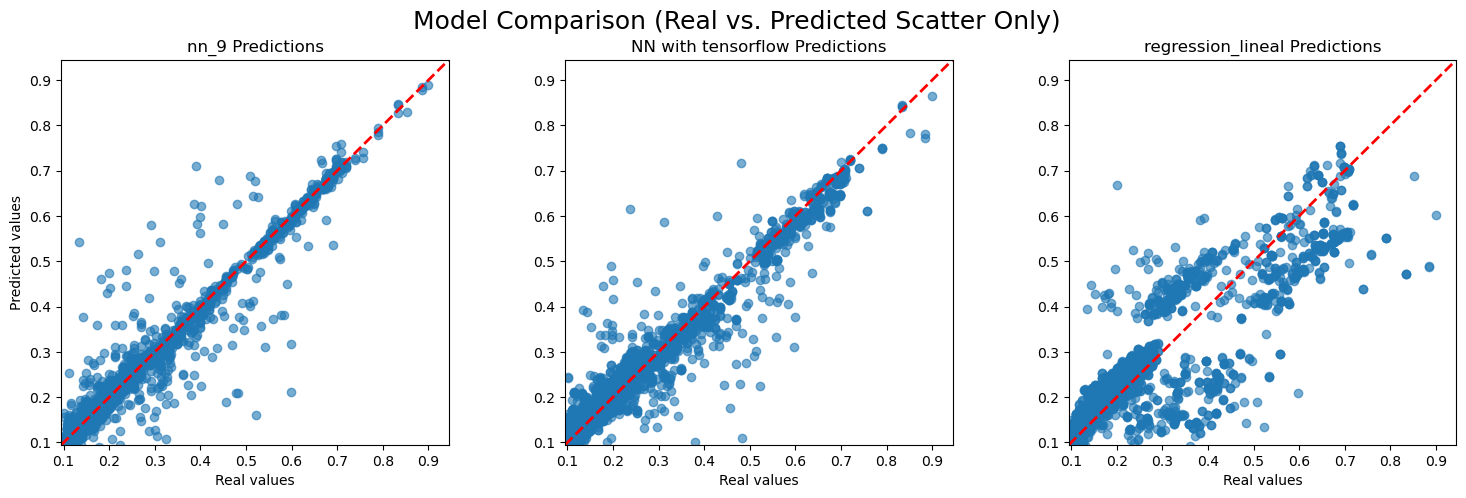

In [157]:
compare_three_nn_performance_individual_loss(
    [
        nn_9,  
        model, 
        model_linear
    ], X_test, y_test, 
    ['nn_9', 'NN with tensorflow', 'regression_lineal'],
    True
)

<pre>
    
2 paragraphs of discussion comparing the results and functionality obtained by
your implementation versus the other models.

In this case, we got the following results for the model using tensorflow:
    MSE 0.001553
    MAE 0.02343
    MAPE 0.10805
Besides, using a simple linear regression, we got
    MSE 0.006111
    MAE 0.051995
    MAPE 0.1938
These two model were compared with NN9, which was the best result using our custom NN.
    MSE 0.001343
    MAE 0.016273
    MAPE 0.073888

Despite using a tensorflow library, it is noticeable that our NN got the lowest MSE, MAE and MAPE overall. This is probably due to the architecture because the tensorflow model was set with less neurons than the custom NN. The custom NN, as was explained above has more neurons and probably this was the crucial factor for learning better patterns and generalise the data in a better way. Therefore, the model is able to learn in a better way. However, tensorflow model is not that bad and show a good performance.

In contrast, the linear regression model was showing the worst metrics. This is probably due to non-linear variables, therefore, the model cannot learn from their patterns. 

Finally, it is important to make a point that the custom NN takes more time and it is not efficient as the tensorflow model. Usually, this labraries are already optimal for this jobs.
</pre>


# Optional Part 1: Study the effect of the different regularization techniques in the Neural Network used in the (BP-F)

In [116]:
nn_with_regularisation = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2,
    use_regularisation=True,
    l1_lambda=1e-4,
    l2_lambda=3e-4
)

In [118]:
nn_with_regularisation.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.005138 - Validation Error: 0.004937
Epoch 100/1000 - Training Error: 0.005130 - Validation Error: 0.004915
Epoch 200/1000 - Training Error: 0.005223 - Validation Error: 0.005007
Epoch 300/1000 - Training Error: 0.005006 - Validation Error: 0.004795
Epoch 400/1000 - Training Error: 0.005027 - Validation Error: 0.004819
Epoch 500/1000 - Training Error: 0.005070 - Validation Error: 0.004862
Epoch 600/1000 - Training Error: 0.005107 - Validation Error: 0.004896
Epoch 700/1000 - Training Error: 0.005025 - Validation Error: 0.004816
Epoch 800/1000 - Training Error: 0.005005 - Validation Error: 0.004796
Epoch 900/1000 - Training Error: 0.005012 - Validation Error: 0.004796


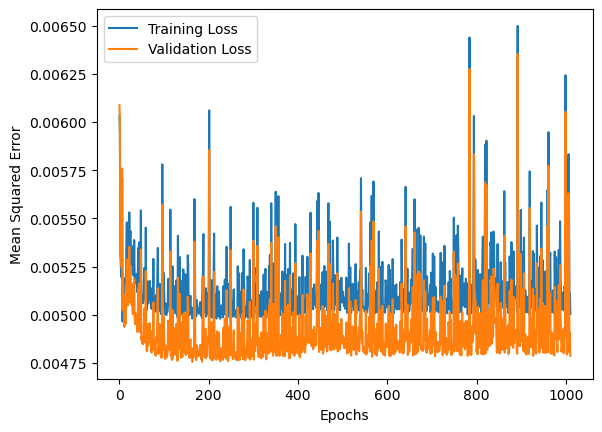

Predictions: [0.22737593 0.12863691 0.17008288 ... 0.24176742 0.12983569 0.1798175 ]


In [158]:
show_loss(nn_with_regularisation, X_test)

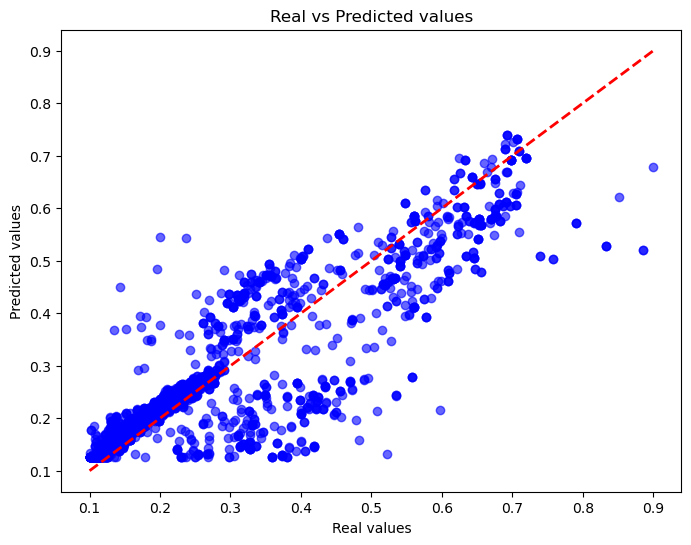

MSE: 0.005017
MAE: 0.044294
MAPE: 64.897315


In [212]:
get_prediction('NN1 with regularisation', nn_with_regularisation, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [201]:
nn_with_regularisation_2 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2,
    use_regularisation=True,
    l1_lambda=1e-4,
    l2_lambda=1e-4
)

In [203]:
nn_with_regularisation_2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.004881 - Validation Error: 0.005415
Epoch 100/1000 - Training Error: 0.004751 - Validation Error: 0.005460
Epoch 200/1000 - Training Error: 0.004628 - Validation Error: 0.005310
Epoch 300/1000 - Training Error: 0.004669 - Validation Error: 0.005321
Epoch 400/1000 - Training Error: 0.004666 - Validation Error: 0.005318
Epoch 500/1000 - Training Error: 0.004864 - Validation Error: 0.005443
Epoch 600/1000 - Training Error: 0.004885 - Validation Error: 0.005621
Epoch 700/1000 - Training Error: 0.004695 - Validation Error: 0.005314
Epoch 800/1000 - Training Error: 0.005120 - Validation Error: 0.005680
Epoch 900/1000 - Training Error: 0.004671 - Validation Error: 0.005295


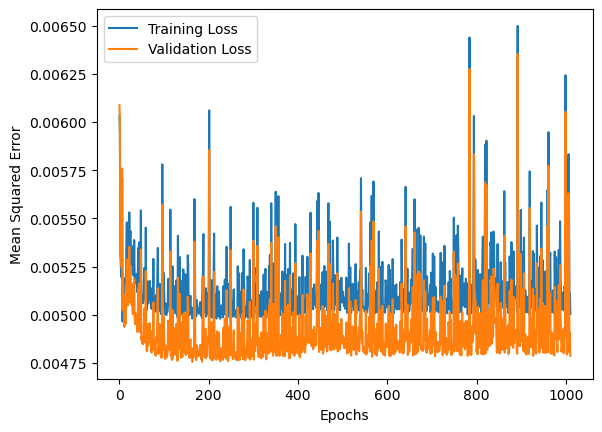

Predictions: [0.60540582 0.26309602 0.14463983 ... 0.56533765 0.18015969 0.22825949]


In [204]:
show_loss(nn_with_regularisation, X_test)

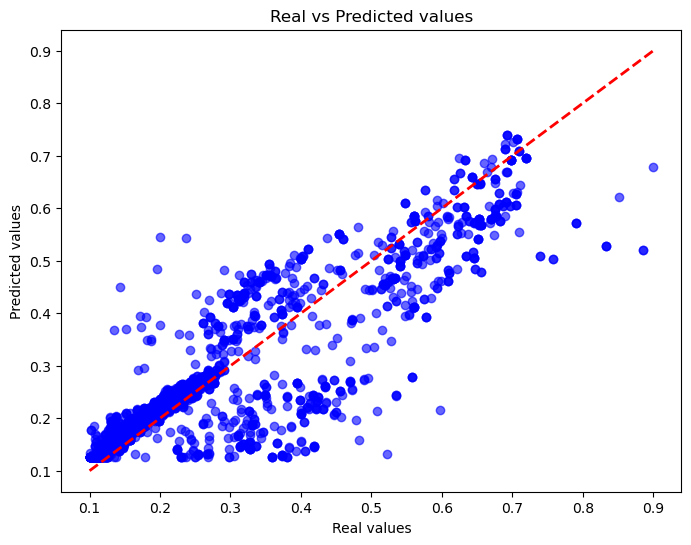

MSE: 0.005017
MAE: 0.044294
MAPE: 64.897315


In [205]:
get_prediction('NN1 with regularisation 2', nn_with_regularisation, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [206]:
nn_with_regularisation_3 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2,
    use_regularisation=True,
    l1_lambda=5e-4,
    l2_lambda=3e-3
)

In [207]:
nn_with_regularisation_3.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006102 - Validation Error: 0.006042
Epoch 100/1000 - Training Error: 0.006723 - Validation Error: 0.006765
Epoch 200/1000 - Training Error: 0.006635 - Validation Error: 0.006672
Epoch 300/1000 - Training Error: 0.006885 - Validation Error: 0.006884
Epoch 400/1000 - Training Error: 0.006638 - Validation Error: 0.006682
Epoch 500/1000 - Training Error: 0.006851 - Validation Error: 0.006917
Epoch 600/1000 - Training Error: 0.006914 - Validation Error: 0.006888
Epoch 700/1000 - Training Error: 0.006576 - Validation Error: 0.006605
Epoch 800/1000 - Training Error: 0.006724 - Validation Error: 0.006774
Epoch 900/1000 - Training Error: 0.006664 - Validation Error: 0.006678


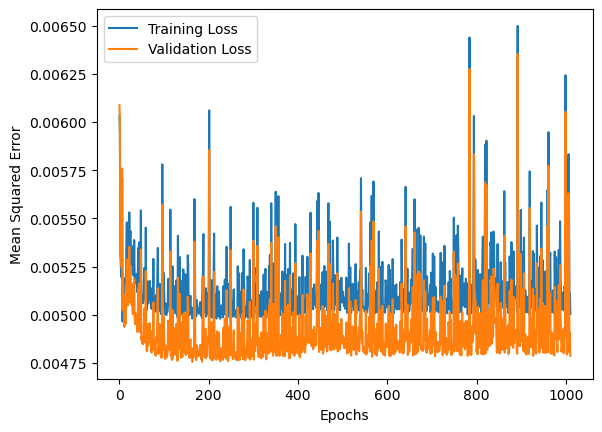

Predictions: [0.60540582 0.26309602 0.14463983 ... 0.56533765 0.18015969 0.22825949]


In [208]:
show_loss(nn_with_regularisation, X_test)

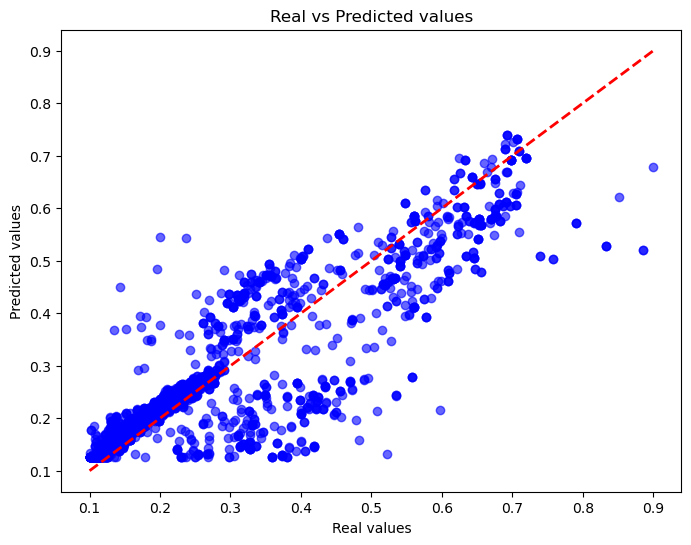

MSE: 0.005017
MAE: 0.044294
MAPE: 64.897315


In [209]:
get_prediction('NN1 with regularisation 3', nn_with_regularisation, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [213]:
save_prediction_to_csv("comparison_with_regularisation.csv", metrics)

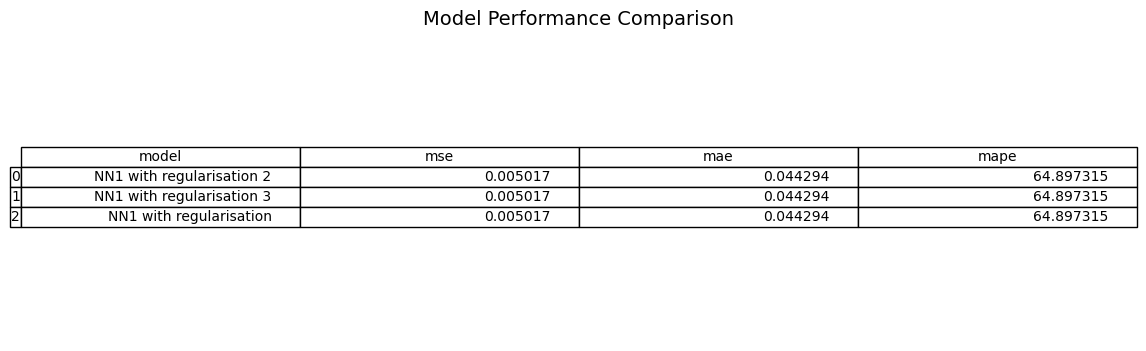

In [215]:
df = pd.read_csv("comparison_with_regularisation.csv")  # change path to your CSV

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

<pre>
For each of the techniques, you should:
- Explain how the regularization is introduced and the parameters used. It is
important to justify why a certain value for a parameter is choosen, and it is
recommended to try different values to observe the results.
- For each of the parameters, present the results of the prediction (evaluation
metrics)


It was added L1 and L2 regularization, L1 adds a penalty based of the absolute value of the weights, the purpose is to get to the exactly 0. This create sparsity(0s). This way, it produces models that depend on only the most important connection. 

L2 adds a penalty based on the square of the weights. It reduces the weights to zero slowly. This helps to reduce overfitting and avoid bigger weights



the following code was added to add these regularization parameters.
</pre>


```

if self.use_regularisation:
    # L1
    # sign(w) is either +1 or -1
    # So we subtract a constant force in the opposite direction of the weight
    # Effect: every step removes the same amount → some weights hit exact 0 and stay there, This creates sparsity
    # example: If w = -0.3, sign(w) = -1
    # We compute λ1 * (-1), then subtract it → + step → weight increases toward 0.
    if self.l1_lambda > 0:
        self.d_w[lay] -= self.learning_rate * (self.l1_lambda * np.sign(self.w[lay]))

    # L2
    # self.w has the same sign as the current weight 
    # We subtract a scaled version of it → moves opposite to weight direction
    # Effect: big weights shrink more, small weights shrink less → smooth decay
    # example If w = 5, we subtract λ2 * 5 → update step becomes negative → weight moves down toward 0.
    if self.l2_lambda > 0:
        self.d_w[lay] -= self.learning_rate * (self.l2_lambda * self.w[lay])               

```

    
<pre>
The first values to try were these ones
    L1 = 0.0001 and L2 = 0.0003
    L1 and L2 = 0.0001
    
    L1 = 0.0005 and L2 = 0.003

Yet, the results are not better than for example the NN9 attempt. This could be that regularization works better
with cross validation. Besides, another issues was found, the regularisation parameters make the loss and eval to behave like a wave.
Even trying to change the values, the metrics are the same. Basically, it's not learning 
</pre>


# Optional Part 2: Introduce Cross Validation in the model selection and validation in your implementation of the neural network

In [189]:
# Kfolds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define grid
param_grid = {
    "learning_rate": [0.001, 0.1],
    "function": ["relu", "tanh", "linear", "sigmoid"],
    "epochs": [500, 1000],
    "L1": [1e-4],
    "L2": [1e-4],
}

keys, values = zip(*param_grid.items())
configurations = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []

for config in configurations:
    mse_scores, mae_scores, mape_scores = [], [], []

    print("Testing:", config)

    for train_idx, test_idx in kf.split(Xs):
        X_train, X_test = Xs.iloc[train_idx], Xs.iloc[test_idx]
        y_train, y_test = ys.iloc[train_idx], ys.iloc[test_idx]

        model = NeuralNet(
            layers=[X_train.shape[1], 64, 64, 1],
            epochs=config["epochs"],
            learning_rate=config["learning_rate"],
            momentum=0.9,
            function=config["function"],
            validation_split=0.2,
            use_regularisation=True,
            l1_lambda=config["L1"],
            l2_lambda=config["L2"]
        )
        
        X_train = X_train.values
        y_train = y_train.values.reshape(-1, 1)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test.values)

        mse_scores.append(mean_squared_error(y_test, y_pred))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))

    # Convert lists to arrays (your snippet)
    mse_scores = np.array(mse_scores)
    mae_scores = np.array(mae_scores)
    mape_scores = np.array(mape_scores)

    # Create summary dataframe (your snippet)
    metrics_summary = pd.DataFrame({
        'Metric': ['MSE', 'MAE', 'MAPE'],
        'Mean': [mse_scores.mean(), mae_scores.mean(), mape_scores.mean()],
        'Std Dev': [mse_scores.std(), mae_scores.std(), mape_scores.std()]
    })

    print(metrics_summary, "\n")

    # Save results for ranking/analysis
    results.append({
        **config,
        "avg_mse": mse_scores.mean(),
        "std_mse": mse_scores.std(),
        "avg_mae": mae_scores.mean(),
        "std_mae": mae_scores.std(),
        "avg_mape": mape_scores.mean(),
        "std_mape": mape_scores.std()
    })

# Optionally sort by best MSE
results = sorted(results, key=lambda x: x["avg_mse"])

print("\nTop 3 best configs:")
for r in results[:3]:
    print(r)2


Testing: {'learning_rate': 0.001, 'function': 'relu', 'epochs': 500, 'L1': 0.0001, 'L2': 0.0001}
Epoch 0/500 - Training Error: 0.006111 - Validation Error: 0.006153
Epoch 100/500 - Training Error: 0.005036 - Validation Error: 0.005161
Epoch 200/500 - Training Error: 0.004825 - Validation Error: 0.004924
Epoch 300/500 - Training Error: 0.004965 - Validation Error: 0.004947
Epoch 400/500 - Training Error: 0.004800 - Validation Error: 0.004871
Epoch 0/500 - Training Error: 0.090904 - Validation Error: 0.088007
Epoch 100/500 - Training Error: 0.090904 - Validation Error: 0.088007
Epoch 200/500 - Training Error: 0.090904 - Validation Error: 0.088007
Epoch 300/500 - Training Error: 0.090904 - Validation Error: 0.088007
Epoch 400/500 - Training Error: 0.090904 - Validation Error: 0.088007
Epoch 0/500 - Training Error: 0.088948 - Validation Error: 0.093934
Epoch 100/500 - Training Error: 0.004841 - Validation Error: 0.005053
Epoch 200/500 - Training Error: 0.004741 - Validation Error: 0.004955

/Users/hjaviersarmientoy/Documents/1_projects/complete_master_in_cybersecurity_and_ia/NEC_neural_and_evolutionary_computation/Activity 1/NeuralNet.py:146: RuntimeWarning: overflow encountered in dot
  self.h[lay] = np.dot(self.w[lay], self.xi[lay - 1]) - self.theta[lay]
/Users/hjaviersarmientoy/Documents/1_projects/complete_master_in_cybersecurity_and_ia/NEC_neural_and_evolutionary_computation/Activity 1/NeuralNet.py:146: RuntimeWarning: invalid value encountered in dot
  self.h[lay] = np.dot(self.w[lay], self.xi[lay - 1]) - self.theta[lay]


Epoch 0/500 - Training Error: nan - Validation Error: nan
Epoch 100/500 - Training Error: nan - Validation Error: nan


KeyboardInterrupt: 

In [210]:
# Result have to be saved manually due to error
# https://stackoverflow.com/questions/7559595/python-runtimewarning-overflow-encountered-in-long-scalars
df = pd.read_csv("cross_validation_and_hyperparamethers.csv")
df = df.sort_values(by="MSE_mean")  # or MAE_mean or MAPE_mean

print(df)


                    model  learning_rate function  epochs      L1      L2  \
1      lr_0.001_relu_1000          0.001     relu    1000  0.0001  0.0001   
2       lr_0.001_tanh_500          0.001     tanh     500  0.0001  0.0001   
3      lr_0.001_tanh_1000          0.001     tanh    1000  0.0001  0.0001   
5    lr_0.001_linear_1000          0.001   linear    1000  0.0001  0.0001   
4     lr_0.001_linear_500          0.001   linear     500  0.0001  0.0001   
7   lr_0.001_sigmoid_1000          0.001  sigmoid    1000  0.0001  0.0001   
6    lr_0.001_sigmoid_500          0.001  sigmoid     500  0.0001  0.0001   
10        lr_0.1_tanh_500          0.100     tanh     500  0.0001  0.0001   
11       lr_0.1_tanh_1000          0.100     tanh    1000  0.0001  0.0001   
0       lr_0.001_relu_500          0.001     relu     500  0.0001  0.0001   
8         lr_0.1_relu_500          0.100     relu     500  0.0001  0.0001   
9        lr_0.1_relu_1000          0.100     relu    1000  0.0001  0.0001   

<pre>
How the cross-validation has been introduced, including the parameters (number
of folds, and/or percentage of training patterns used, ..)
- Present the cross-validation results in the table format presented before, showing
the mean and standard deviation of each performance metric (MSE, MAE,
MAPE) for each model.
- Analyze the cross-validation results to determine which model generalizes best
to unseen data.



To add cross validation to the model, it was used KFold library from sklearn. This library allow us to make the folds of our dataset. This values are usually 3, 5 or 10.  In this case, 5 folds were selected as a good balance between training cost and model evaluation.

This will create 5 different partitions of the dataset. In each iteration, one fold is used as the test set (20%), while the rest four folds are used for training (80%). The model is therefore trained five individual times, each with a different portion of unseen data for evaluation. As a result, the model can generalize better, reduce overfitting, and become more robust when predicting unknown samples.

As can be seen in the table the best results are comparing the different metrics. 

    lr_0.001_relu_1000
    Best overall among the top 3
    Lowest MSE mean (0.004922) 
    Lowest MAE mean (0.043506)
    MAPE (0.165372) is also the smallest
    Std values are low, performance is stable across folds

    lr_0.001_tanh_500
    Slightly higher errors than Model 1
    MSE  (0.005479)
    MAE  (0.047316)
    MAPE  (0.175921)
    Still quite stable (low std), reliable but not the best

    lr_0.001_tanh_1000
    Similar MSE to Model 2, but worst MAPE (0.203454) 
    Highest MAE std (0.009205) - less consistent predictions across folds
    More capacity (1000 epochs) didn't help, may indicate: Overfitting

    
However, it is not comparable with the result of the NN9, which has better metrics than this attemps with different configurations.

It is important to mention that unfortunately due to an error (# https://stackoverflow.com/questions/7559595/python-runtimewarning-overflow-encountered-in-long-scalars) while executing the 13/16 iteration. We got the problem of types, basically the weights are bigger than int32 and caused an issues, as can been seen in the output. However, the results were collected for analysis and this can be run again later.
</pre>


# Optional Part 3: Ensemble Learning Models

### XGBoost

In [223]:
# Create an XGBRegressor
ensemble = {}
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


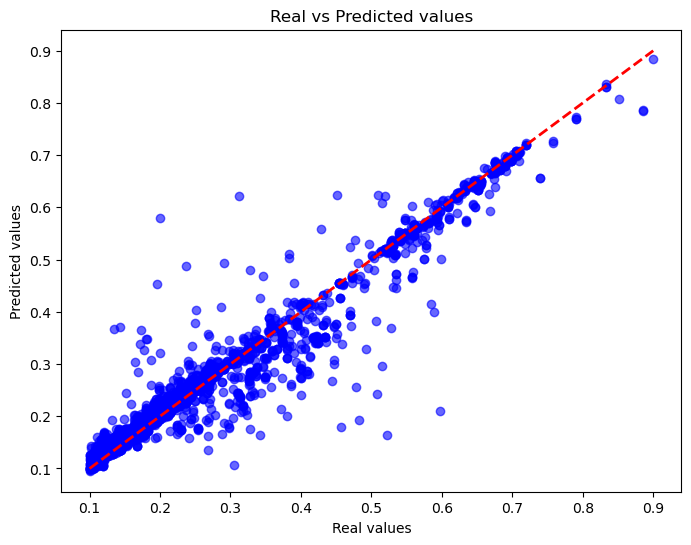

MSE: 0.001269
MAE: 0.018121
MAPE: 7.68449


In [224]:
get_prediction('XGBboost', model, X_test, y_test, y_train, ensemble, show_prediction_vs_real=True)

In [225]:
from sklearn.ensemble import RandomForestRegressor
# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

/Users/hjaviersarmientoy/miniforge3/envs/jupyter_m1/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


/Users/hjaviersarmientoy/miniforge3/envs/jupyter_m1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


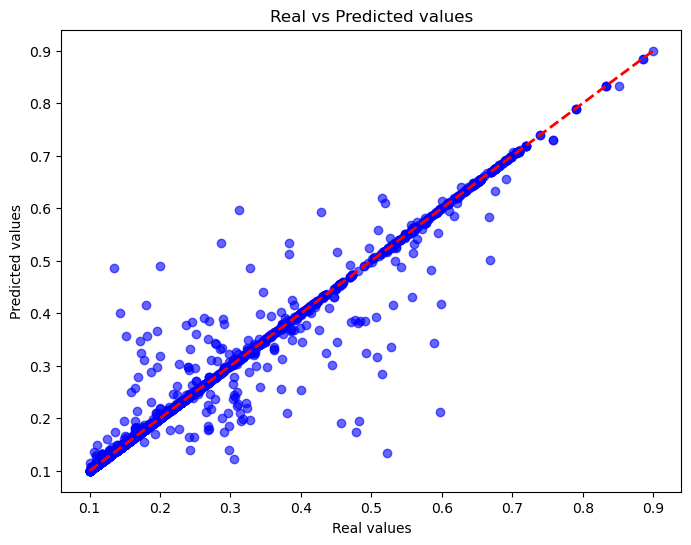

MSE: 0.00079
MAE: 0.005714
MAPE: 2.042532


In [226]:
get_prediction('Random Forest', model_rf, X_test, y_test, y_train, ensemble, show_prediction_vs_real=True)

In [227]:
save_prediction_to_csv("ensemble.csv", ensemble)

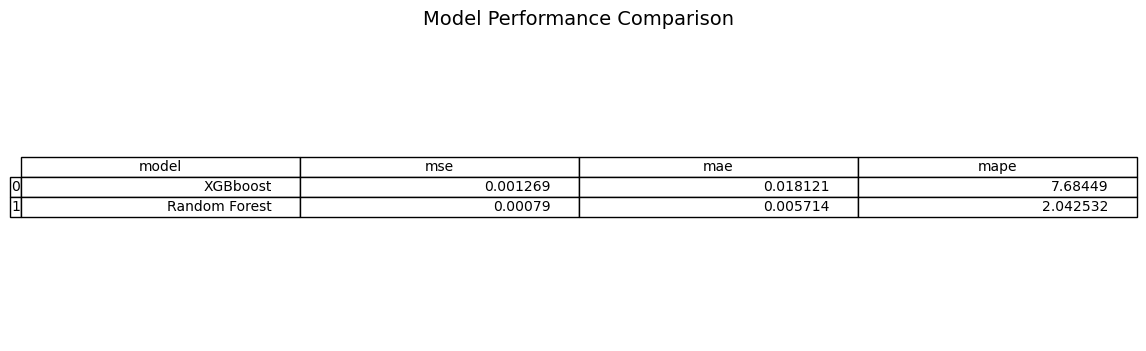

In [228]:
df = pd.read_csv("ensemble.csv")  # change path to your CSV

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

<pre>
For this part, you should include in your report:
- A description of the ensemble methods that you have implemented or used,
explaining briefly how each one works and what parameters have been selected.
- The values of the parameters chosen for each ensemble method, and the
justification of these choices.
- A comparison of the results obtained against the other models, with an analysis of
the main differences.



The ensemble regression methods implemented were Random Forest and XGBoost.
Random Forest is an algorithm that trains many decision trees in parallel using random subsets of data and features, and averages their predictions. It is specifically strong when it tries to reduce variance and tackling noisy or scaled data. In this case, the parameters were chosen to get a benefit of stability and generalization, using a relatively large number of trees and controlled depth to capture patterns without overfitting.

XGBoost is a boosting algorithm that builds trees sequentially, where each new tree learns from the errors of the previous ones by optimizing a loss function using gradient descent. The parameters selected prioritized slow, small updates and regularization, applying a low learning rate and multiple boosting rounds to prevent bad correction and improve generalisation. However, boosting models are naturally more sensitive to input scale and noise, so errors can accumulate if tuning is not extremely precise.

When comparing results to other models, Random Forest achieved significantly lower MSE, MAE, and MAPE than XGBoost. This can said that averaging independent trees was more effective for this normalised regression task, where the target values lie in a narrow range. XGBoost, while powerful for learning residual errors, likely struggled because the dataset scale and noise made optimization harder, allowing residual mistakes to propagate through boosting iterations. The performance gap highlights that random forest was more robust and better with the data characteristics than boosting for this specific problem.

Keep in mind, that Random Forest got the best mse over the mse from NN9 results above.
    
</pre>

References

- slides seen in class, U3 both slides
- BP.v2

NN with tensor flow
https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
https://www.tensorflow.org/guide/keras/sequential_model
https://numustafa.medium.com/deep-learning-neural-network-for-regression-with-tensorflow-f87968173520

Linear regression with NN
https://www.tensorflow.org/tutorials/keras/regression
https://pyimagesearch.com/2021/05/06/backpropagation-from-scratch-with-python/

https://mmuratarat.github.io/2020-01-09/backpropagation
https://udlbook.github.io/udlbook/


https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap06/6_4_Momentum.ipynb
https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap07/7_2_Backpropagation.ipynb
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

https://anshulhep.medium.com/make-your-tensorflow-keras-predictions-faster-with-batch-size-8bbd780b9c08

https://www.quora.com/What-is-an-intuitive-explanation-of-momentum-in-training-neural-networks

Implementing cross validation
https://scikit-learn.org/stable/modules/cross_validation.html
https://medium.com/@avijit.bhattacharjee1996/implementing-k-fold-cross-validation-from-scratch-in-python-ae413b41c80d
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

https://www.geeksforgeeks.org/machine-learning/hebbian-learning-rule-with-implementation-of-and-gate/
